# 03 · DESI DR2 BAO

Nine cosmological scenarios over **DESI BAO DR2** (Gaussian likelihood), from
the simplest (wCDM 2D) to the most constrained (5D with full Planck + SNe + BAO
priors).

All scenarios share the same recipe:
- Sampling: `build_chi2_dataset` with slices + random cloud, cached in `outputs/datasets/`.
- Training: `train_xgb(log_target=True, ...)` with model cache.
- XGBoost hyperparameters: `n_estimators=3000, learning_rate=0.03, max_depth=10`,
  `tree_method='hist'`, early stopping with `min_delta=1e-4`.
- Contours: `res=100, sigma=2.0, theory_threshold=12` with zoom on the best-fit.
- SHAP values in shifted-log10 chi2 (a contribution of 0.5 ~ factor x3 in chi2).

### File convention

Each section uses `SECTION = "3_X"` as a prefix:
- Dataset:  `outputs/datasets/{SECTION}_dataset.csv`
- Model:    `outputs/models/{SECTION}_model.ubj` (+ `.info.pkl`)
- Figures:  `outputs/figures/03_BAO/{SECTION}_*.png`


## Index

| Sec. | Scenario                                | Dim | Free parameters                          | Notes |
|------|-----------------------------------------|-----|------------------------------------------|-------|
| [3.1](#3-1) | **wCDM**                          | 2   | Om, w                                    | Baseline; wa=0; H0, rd at Planck |
| [3.2](#3-2) | **wCDM with H0 free**             | 3   | Om, w, H0                                | rd fixed at Planck |
| [3.3](#3-3) | **w0waCDM (full DESI)**           | 3   | Om, w0, wa                               | Main result: LCDM disfavored at >4 sigma |
| [3.4](#3-4) | **w0waCDM (z < 2)**               | 3   | Om, w0, wa                               | Drops the Lyman-alpha point (z=2.33) |
| [3.5](#3-5) | **w0waCDM + rd=Planck**           | 4   | Om, w0, wa, H0                           | rd fixed, H0 free |
| [3.6](#3-6) | **w0waCDM with H0*rd**            | 4   | Om, w0, wa, **H0*rd**                    | BAO depends only on the product H0*rd |
| [3.7](#3-7) | **H0–rd degeneracy (SHAP)**       | 5   | Om, w0, wa, H0, rd (no priors)           | SHAP demonstration of the degeneracy |
| [3.8](#3-8) | **w0waCDM + 3 Planck priors**     | 5   | Om, w0, wa, H0, rd (Gaussian Om, H0, rd) | Combines BAO with early-universe priors |
| [3.9](#3-9) | **w0waCDM + 5 Planck priors**     | 5   | Om, w0, wa, H0, rd (priors on all)       | Most constrained scenario |


## <a id="setup"></a>Setup (run first)


In [225]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd
import scipy.optimize as opt
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.data import load_desi_bao
from cosmoml.theory.bao import chi2_bao
from cosmoml.priors import planck_prior_chi2, gaussian_prior
from cosmoml.sampling import build_chi2_dataset, load_or_build
from cosmoml.ml import (
    train_xgb, plot_contour_2d, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all,
    use_paper_style,
)
from cosmoml.config import OUTPUTS_DIR, PLANCK_H0, PLANCK_RD, PLANCK_OM

use_paper_style()

bao_full = load_desi_bao()
bao_z2   = load_desi_bao(z_max=2.0)
print(f"DESI BAO completo: {len(bao_full)} medidas en {len(bao_full.unique_z)} redshifts {bao_full.unique_z}")
print(f"DESI BAO z<2:      {len(bao_z2)} medidas en {len(bao_z2.unique_z)} redshifts {bao_z2.unique_z}")

NB_NAME = "03_BAO"
DATASETS_DIR = OUTPUTS_DIR / "datasets"
MODELS_DIR   = OUTPUTS_DIR / "models"
FIGURES_DIR  = OUTPUTS_DIR / "figures" / NB_NAME
for d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN = False
print(f"\nDatasets:  {DATASETS_DIR}/{{SECTION}}_dataset.csv")
print(f"Models:    {MODELS_DIR}/{{SECTION}}_model.ubj  (FORCE_RETRAIN={FORCE_RETRAIN})")
print(f"Figures:   {FIGURES_DIR}/{{SECTION}}_*.png")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
DESI BAO completo: 13 medidas en 7 redshifts [0.295 0.51  0.706 0.934 1.321 1.484 2.33 ]
DESI BAO z<2:      11 medidas en 6 redshifts [0.295 0.51  0.706 0.934 1.321 1.484]

Datasets:  /home/aleja/PhysicsML/CosmoML/outputs/datasets/{SECTION}_dataset.csv
Models:    /home/aleja/PhysicsML/CosmoML/outputs/models/{SECTION}_model.ubj  (FORCE_RETRAIN=False)
Figures:   /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/{SECTION}_*.png


## <a id="3-1"></a>3.1 wCDM — 2D (Om, w)

**Model:** `FlatwCDM` with wa=0 fixed. H0 and rd fixed at Planck.
**Data:** DESI BAO DR2 (all redshifts).
**Purpose:** simplest baseline for visualizing the Om–w degeneracy without
the complication of wa.


In [226]:
SECTION = "3_1"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w"]

def chi2_fn(Om, w):
    return chi2_bao(bao_full, Om=Om, w0=w, wa=0.0, H0=PLANCK_H0, rd=PLANCK_RD)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0])))
_m.limits = [(0.2, 0.45), (-1.6, -0.4)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w={REF['w']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2986  w=-0.8841
chi2(best-fit) = 9.20


In [227]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        random_box=dict(Om=(0.1, 0.6), w=(-3.0, 0.0)),
        n_random=12_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_1_dataset.csv)
Evaluating chi2 at 12000 points across 11 cores...
     2000/12000 ( 16.7%) | elapsed    6.4s | ETA   31.8s |    315 pts/s
     4000/12000 ( 33.3%) | elapsed    7.1s | ETA   14.2s |    563 pts/s
     6000/12000 ( 50.0%) | elapsed    8.2s | ETA    8.2s |    733 pts/s
     8000/12000 ( 66.7%) | elapsed   12.9s | ETA    6.4s |    622 pts/s
    10000/12000 ( 83.3%) | elapsed   13.8s | ETA    2.8s |    726 pts/s
    12000/12000 (100.0%) | elapsed   14.9s | ETA    0.0s |    808 pts/s
  done in 15.2s
  saved: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_1_dataset.csv (12000 rows)
min chi2 = 9.202


In [228]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  dropping 4 rows with chi2 >= 90000.0 (sentinels)
  target in shifted-log10: range [0.000, 4.954]


  training: 109.41s | R2=0.99862 | best_iter=528/3000  (early stop, ~82% saved)
  model cached: 3_1_model.ubj


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_learning_curve.png


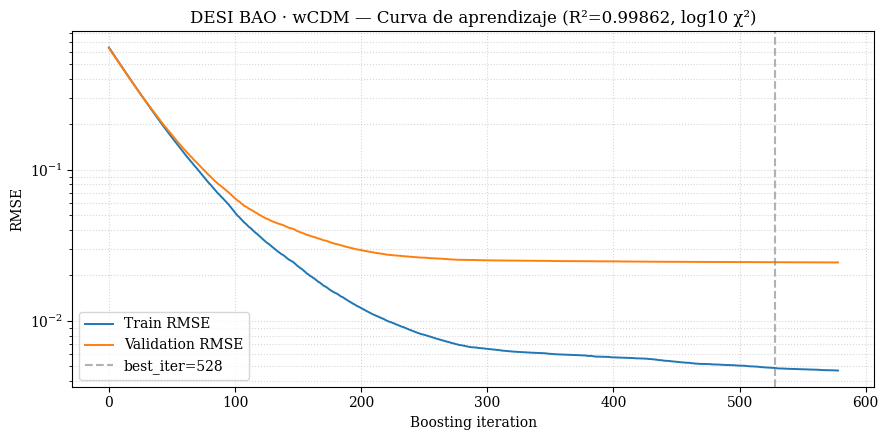

In [229]:
plot_learning_curve(
    info,
    title=f"DESI BAO · wCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w$ vs $\Omega_m$  ({}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_Om_w.png


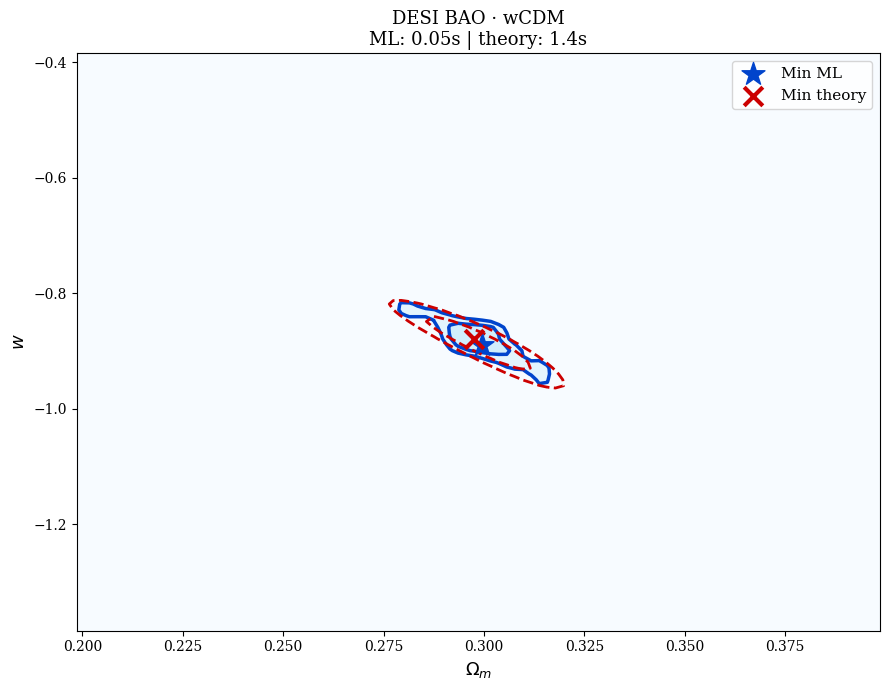

{'Z_ml': array([[6213.7607 , 6116.851  , 5950.641  , ...,  165.02168,  165.20674,
          167.4003 ],
        [6128.6333 , 6024.016  , 5854.553  , ...,  163.43195,  163.61087,
          165.76599],
        [6005.5103 , 5894.385  , 5724.126  , ...,  160.02446,  160.34114,
          162.47224],
        ...,
        [1269.8068 , 1281.9972 , 1289.0144 , ..., 3209.7754 , 3251.3813 ,
         3273.3008 ],
        [1345.7439 , 1357.8191 , 1363.8395 , ..., 3279.2583 , 3321.308  ,
         3344.2583 ],
        [1438.7311 , 1450.7734 , 1456.6255 , ..., 3380.0986 , 3423.3174 ,
         3447.2554 ]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.04811716079711914,
 'time_th': 1.4386925697

In [230]:
common = dict(res=100, sigma=0.8, theory_threshold=30)

plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w",
    x_range=(REF['Om']-0.10, REF['Om']+0.10),
    y_range=(REF['w']-0.50, REF['w']+0.50),
    fixed={},
    theory_fn=chi2_fn,
    title=r"DESI BAO · wCDM",
    x_label=r"$\Omega_m$", y_label=r"$w$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_w.png",
    show=True, **common,
    global_min_chi2=res_opt.fun,
)


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_beeswarm.png


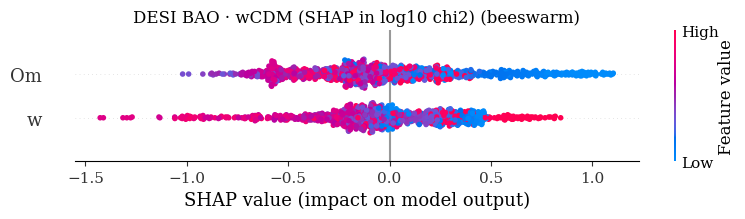

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_bar.png


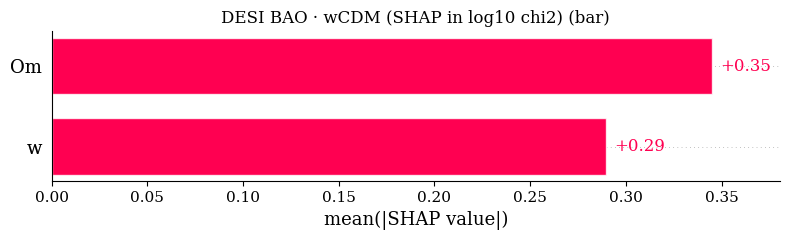

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_waterfall.png


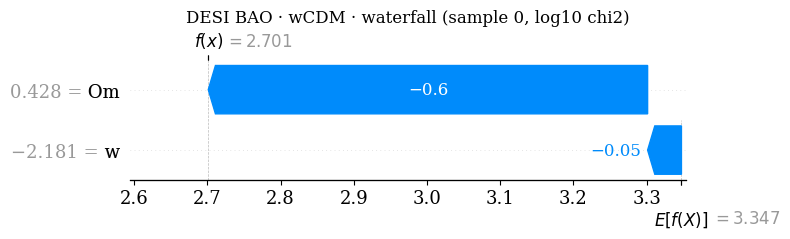

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_Om.png


<Figure size 640x480 with 0 Axes>

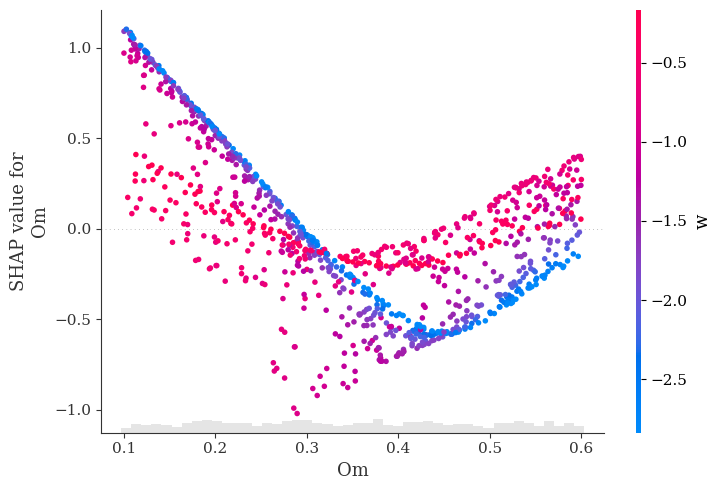

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_w.png


<Figure size 640x480 with 0 Axes>

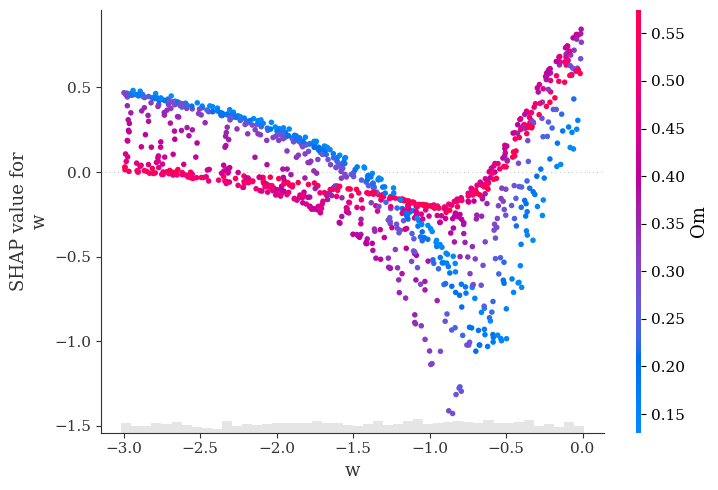

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_1_shap_w.png')]

In [231]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO · wCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO · wCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-2"></a>3.2 wCDM with H0 free — 3D (Om, w, H0)

**Model:** `FlatwCDM` with wa=0 fixed. H0 free, rd fixed at Planck.
**Data:** DESI BAO DR2.
**Purpose:** study the H0–w degeneracy with rd fixed. Without external priors,
BAO alone cannot pin H0 when rd is fixed, so the H0 contours are wide.


In [232]:
SECTION = "3_2"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w", "H0"]

def chi2_fn(Om, w, H0):
    return chi2_bao(bao_full, Om=Om, w0=w, wa=0.0, H0=H0, rd=PLANCK_RD)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0, 67.36])))
_m.limits = [(0.2, 0.45), (-1.6, -0.4), (55, 85)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w={REF['w']:.4f}  H0={REF['H0']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2977  w=-0.9119  H0=67.8159
chi2(best-fit) = 9.04


In [233]:
def builder():
    N = 10_000
    pares = [('Om','w'), ('Om','H0'), ('w','H0')]
    rangos = dict(Om=(0.05, 0.6), w=(-2.5, 0.0), H0=(50, 90))
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=0,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_2_dataset.csv)
Evaluating chi2 at 30000 points across 11 cores...
     2000/30000 (  6.7%) | elapsed   11.3s | ETA  157.7s |    178 pts/s
     4000/30000 ( 13.3%) | elapsed   11.5s | ETA   74.5s |    349 pts/s
     6000/30000 ( 20.0%) | elapsed   11.6s | ETA   46.6s |    515 pts/s
     8000/30000 ( 26.7%) | elapsed   11.9s | ETA   32.6s |    675 pts/s
    10000/30000 ( 33.3%) | elapsed   12.0s | ETA   24.1s |    830 pts/s
    12000/30000 ( 40.0%) | elapsed   12.2s | ETA   18.4s |    981 pts/s
    14000/30000 ( 46.7%) | elapsed   12.6s | ETA   14.4s |   1110 pts/s
    16000/30000 ( 53.3%) | elapsed   12.8s | ETA   11.2s |   1254 pts/s
    18000/30000 ( 60.0%) | elapsed   13.0s | ETA    8.7s |   1387 pts/s
    20000/30000 ( 66.7%) | elapsed   13.1s | ETA    6.6s |   1521 pts/s
    22000/30000 ( 73.3%) | elapsed   13.4s | ETA    4.9s |   1641 pts/s
    24000/30000 ( 80.0%) | elapsed   13.6s | ETA    3.4s |  

In [234]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  dropping 134 rows with chi2 >= 90000.0 (sentinels)
  target in shifted-log10: range [0.000, 4.953]
  training: 120.41s | R2=0.99839 | best_iter=1095/3000  (early stop, ~63% saved)
  model cached: 3_2_model.ubj


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_learning_curve.png


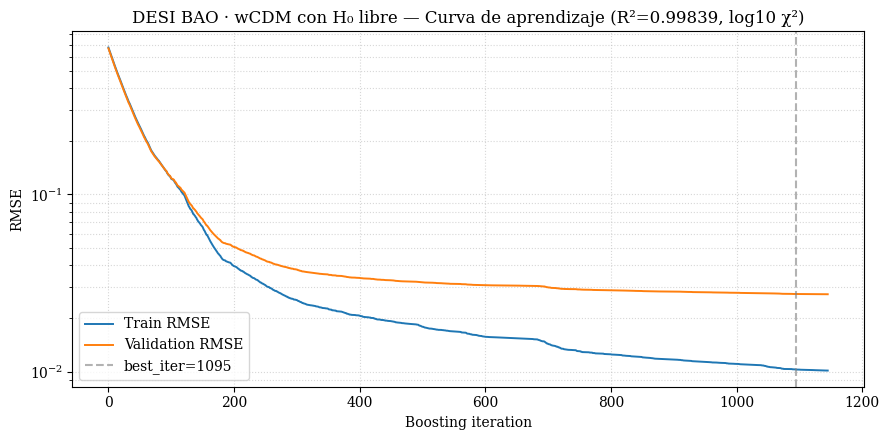

In [235]:
plot_learning_curve(
    info,
    title=f"DESI BAO · wCDM con H₀ libre — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w$ vs $\Omega_m$  ({'H0': 67.81587772788976}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_Om_w.png


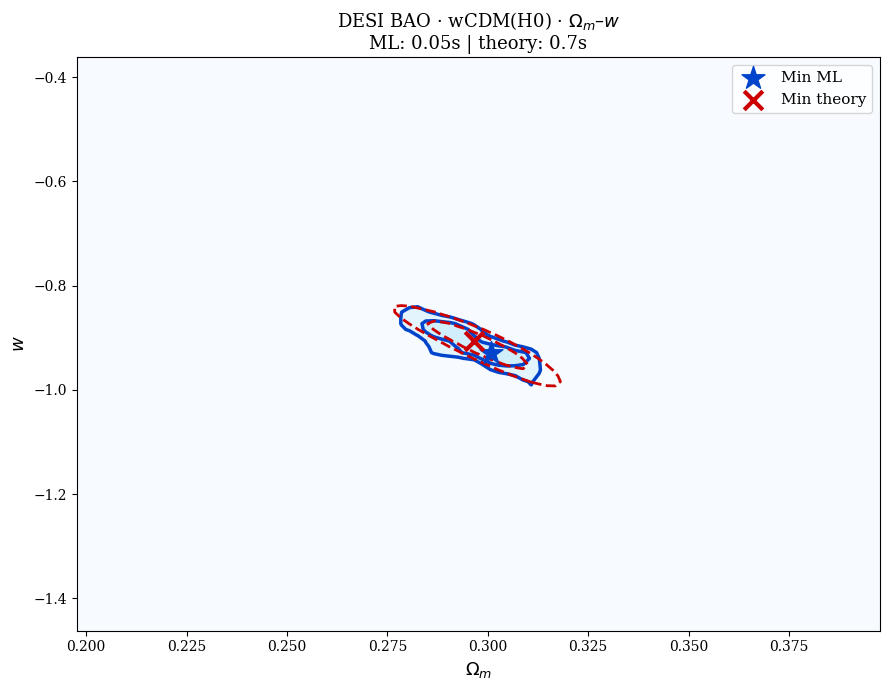

--- $H_0$ vs $\Omega_m$  ({'w': -0.9118867344323001}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_Om_H0.png


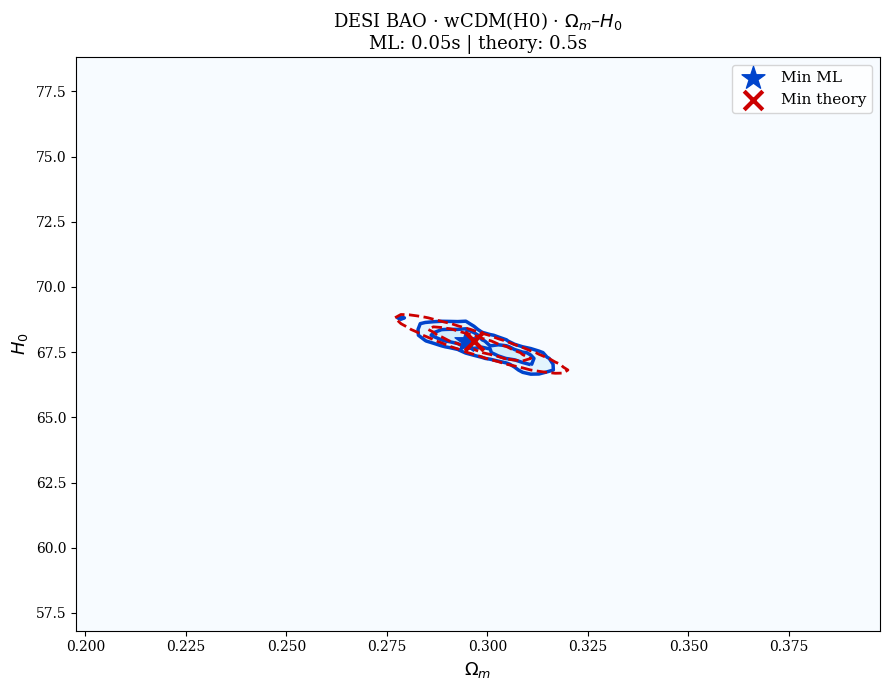

--- $H_0$ vs $w$  ({'Om': 0.29768770044063175}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_w_H0.png


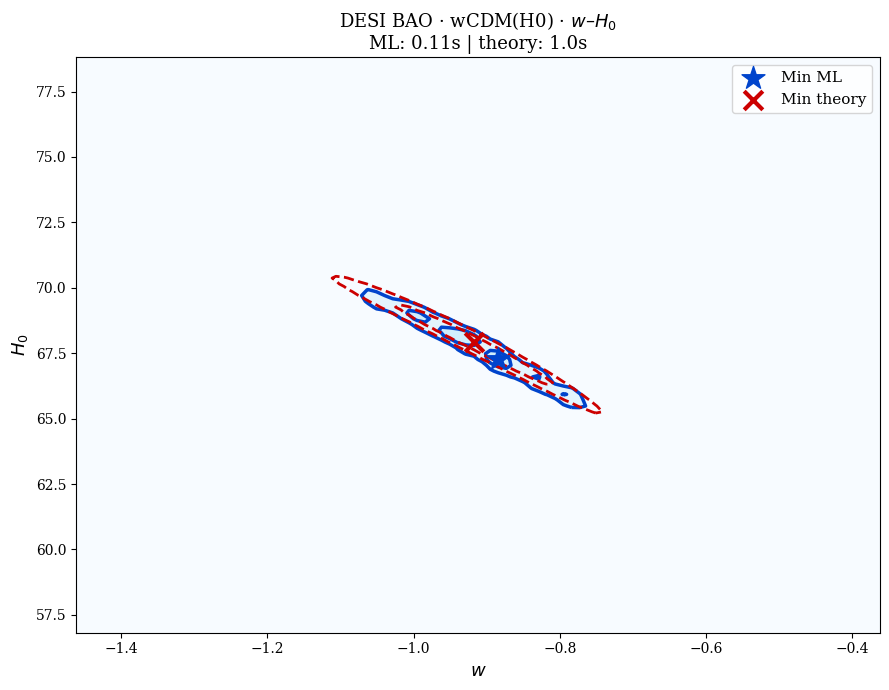

In [236]:
common = dict(res=100, sigma=0.8, theory_threshold=30)
RANGES = dict(
    Om=(REF['Om']-0.10, REF['Om']+0.10),
    w=(REF['w']-0.55, REF['w']+0.55),
    H0=(REF['H0']-11, REF['H0']+11),
)
LABELS = dict(Om=r"$\Omega_m$", w=r"$w$", H0=r"$H_0$")

for x, y in [('Om','w'), ('Om','H0'), ('w','H0')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DESI BAO · wCDM(H0) · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_beeswarm.png


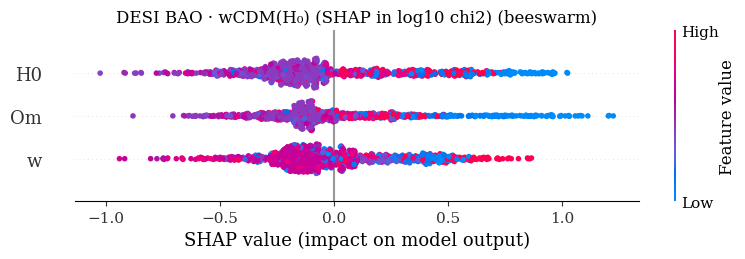

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_bar.png


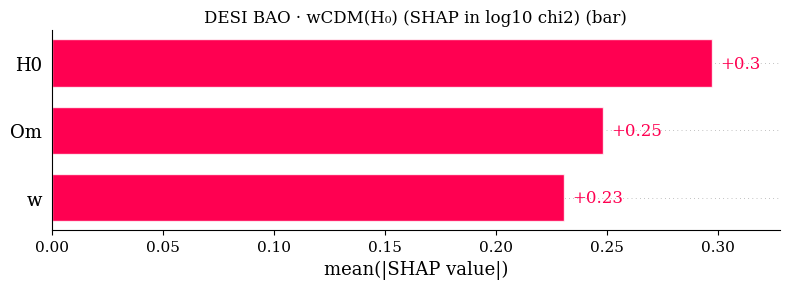

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_waterfall.png


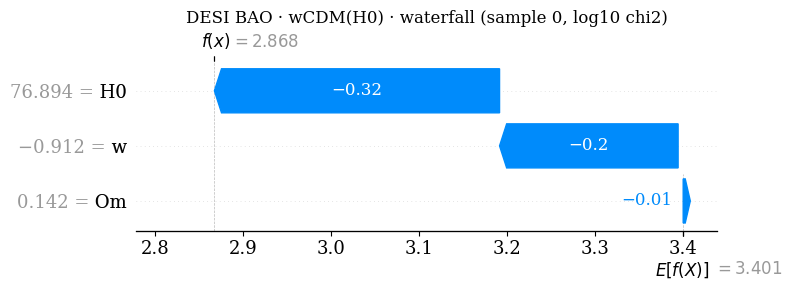

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_Om.png


<Figure size 640x480 with 0 Axes>

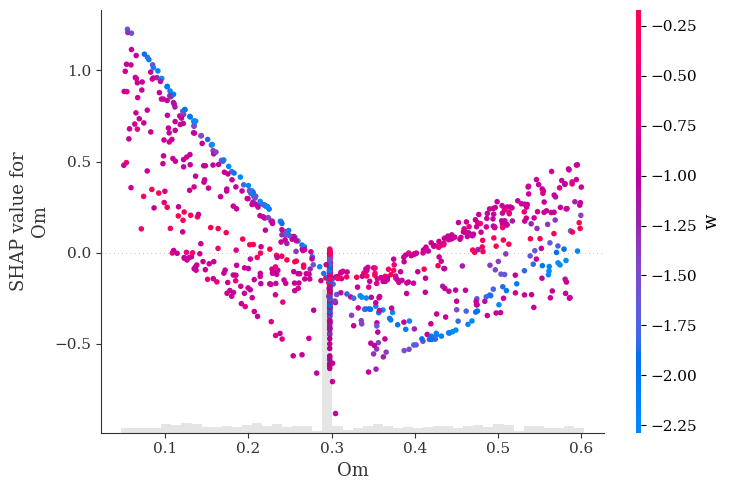

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_w.png


<Figure size 640x480 with 0 Axes>

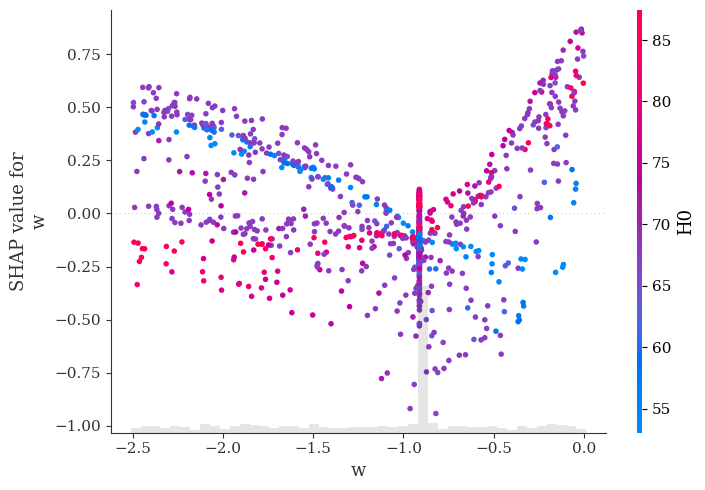

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_H0.png


<Figure size 640x480 with 0 Axes>

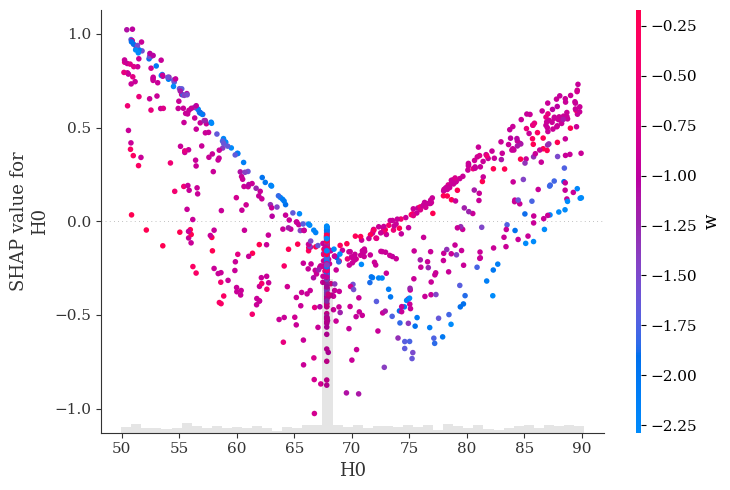

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_w.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_2_shap_H0.png')]

In [237]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO · wCDM(H₀) (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO · wCDM(H0) · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-3"></a>3.3 w0waCDM with full DESI — 3D

**Model:** `Flatw0waCDM` (CPL). H0 and rd fixed at Planck.
**Data:** DESI BAO DR2 (all redshifts, including the Lyman-alpha point at z=2.33).
**Purpose:** **main result of the paper.** With the full DESI dataset, LambdaCDM
(w0=-1, wa=0) is disfavored at more than 4 sigma — the 1-sigma and 2-sigma
contours are tight and exclude the cosmological constant model.


In [278]:
SECTION = "3_3"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]

def chi2_fn(Om, w0, wa):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=PLANCK_H0, rd=PLANCK_RD)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0, 0.0])))
_m.limits = [(0.2, 0.42), (-1.6, -0.5), (-2.0, 1.0)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3135  w0=-0.8305  wa=-0.4873
chi2(best-fit) = 8.25


In [279]:
def builder():
    N = 12_000
    pares = [('Om', 'w0'), ('Om', 'wa'), ('w0', 'wa')]
    # Rangos centrados en REF para densidad suficiente cerca del mínimo
    rangos = dict(
        Om=(REF['Om']-0.10, REF['Om']+0.10),
        w0=(REF['w0']-0.55, REF['w0']+0.55),
        wa=(REF['wa']-2.20, REF['wa']+2.20),
    )
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices,
        random_box=dict(Om=(0.1, 0.6), w0=(-3.0, 1.0), wa=(-4.0, 4.0)),
        n_random=25_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_3_dataset.csv)
Evaluating chi2 at 49000 points across 11 cores...
     2000/49000 (  4.1%) | elapsed    2.9s | ETA   67.0s |    702 pts/s
     4000/49000 (  8.2%) | elapsed    2.9s | ETA   32.5s |   1385 pts/s
     6000/49000 ( 12.2%) | elapsed    3.1s | ETA   22.4s |   1920 pts/s
     8000/49000 ( 16.3%) | elapsed    3.4s | ETA   17.3s |   2376 pts/s
    10000/49000 ( 20.4%) | elapsed    3.6s | ETA   14.0s |   2787 pts/s
    12000/49000 ( 24.5%) | elapsed    3.9s | ETA   11.9s |   3112 pts/s
    14000/49000 ( 28.6%) | elapsed    4.1s | ETA   10.3s |   3406 pts/s
    16000/49000 ( 32.7%) | elapsed    4.4s | ETA    9.0s |   3665 pts/s
    18000/49000 ( 36.7%) | elapsed    4.6s | ETA    8.0s |   3890 pts/s
    20000/49000 ( 40.8%) | elapsed    4.9s | ETA    7.1s |   4091 pts/s
    22000/49000 ( 44.9%) | elapsed    5.2s | ETA    6.3s |   4267 pts/s
    24000/49000 ( 49.0%) | elapsed    5.4s | ETA    5.7s |  

In [280]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  dropping 5 rows with chi2 >= 90000.0 (sentinels)
  target in shifted-log10: range [0.000, 4.949]
  training: 36.61s | R2=0.99667 | best_iter=869/3000  (early stop, ~71% saved)
  model cached: 3_3_model.ubj


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_learning_curve.png


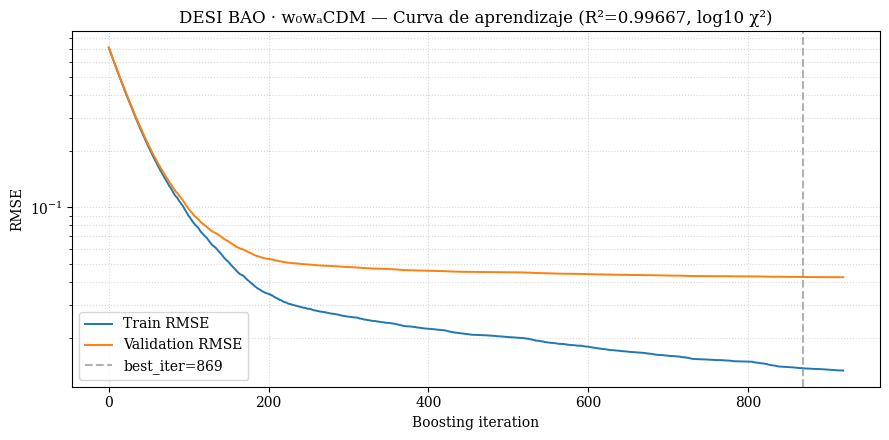

In [281]:
plot_learning_curve(
    info,
    title=f"DESI BAO · w₀wₐCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_a$ vs $w_0$  ({'Om': 0.20973932679461613}) ---
  computing theory (parallel)...


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_w0_wa.png


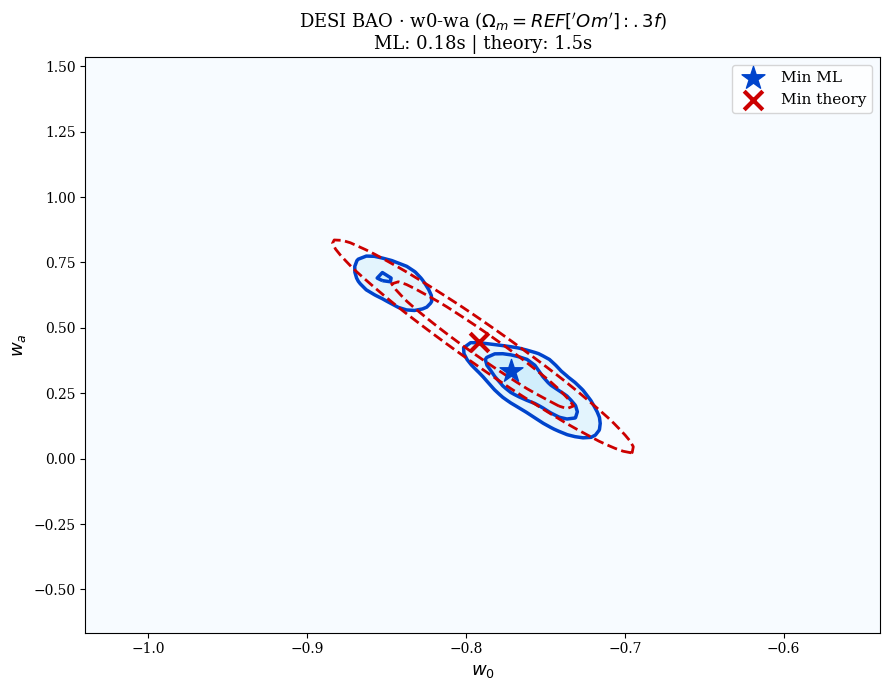

--- $w_0$ vs $\Omega_m$  ({'wa': 0.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_Om_w0.png


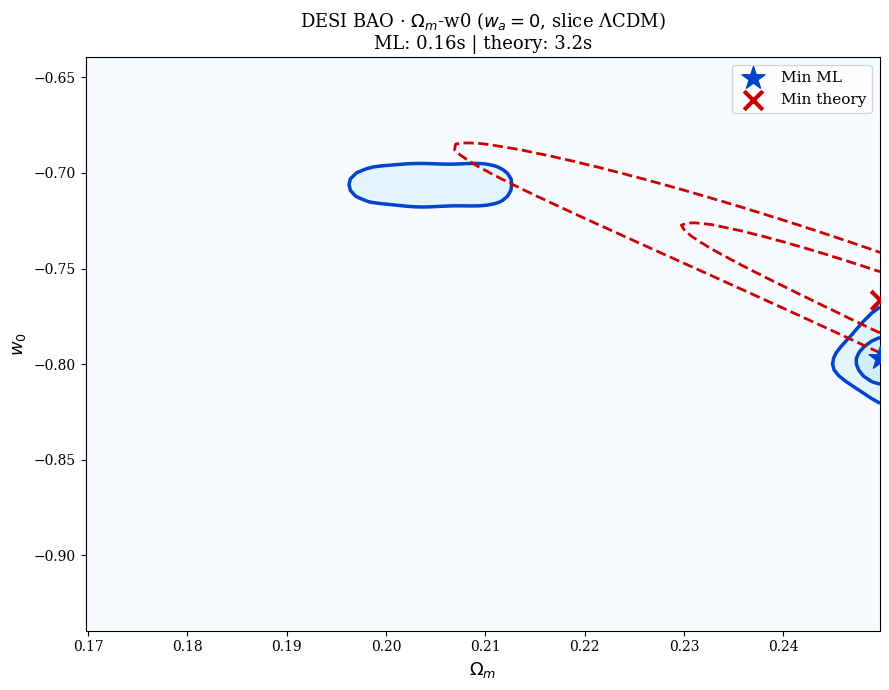

--- $w_a$ vs $\Omega_m$  ({'w0': -1.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_Om_wa.png


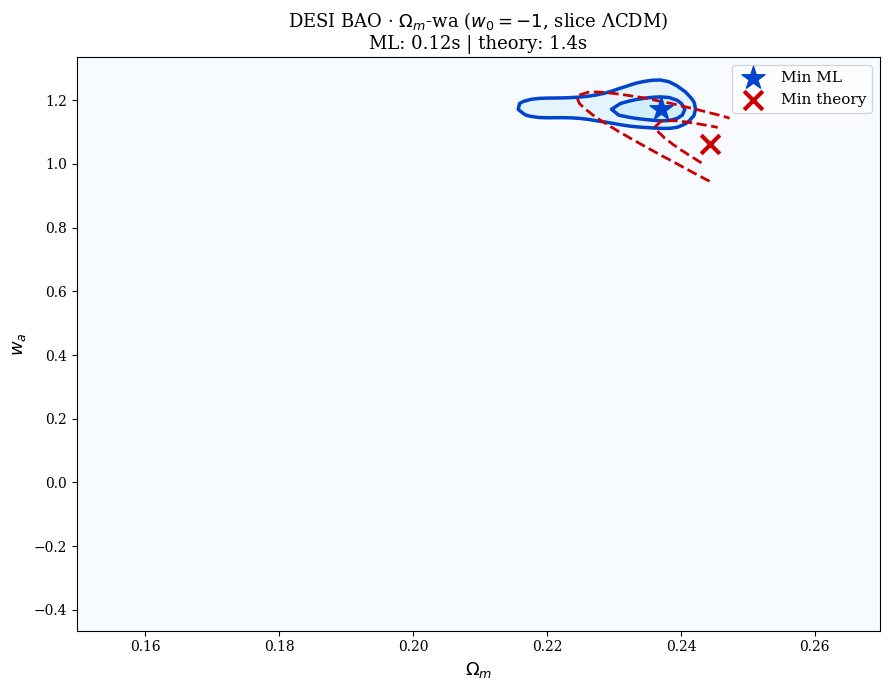

{'Z_ml': array([[4523.851  , 4498.9697 , 4450.775  , ...,  484.58093,  488.53207,
          490.9743 ],
        [4462.048  , 4434.2324 , 4381.579  , ...,  479.51395,  483.4843 ,
          485.91962],
        [4350.042  , 4317.191  , 4256.8867 , ...,  471.55057,  475.56894,
          477.99496],
        ...,
        [ 177.51788,  174.0451 ,  167.575  , ...,  148.48616,  148.10611,
          147.87462],
        [ 174.09964,  170.69885,  164.35127, ...,  150.53421,  150.07637,
          149.79123],
        [ 171.96779,  168.60986,  162.33495, ...,  151.4887 ,  150.98122,
          150.66177]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.11988639831542969,
 'time_th': 1.3592360019

In [297]:
# Full DESI strongly disfavors LCDM (>4 sigma): zoom on the best-fit.
common = dict(res=100, sigma=2.0, theory_threshold=30)

# (1) w0-wa at the best-fit Om: this slice contains the global minimum
plot_contour_2d(
    model, features=FEATURES,
    x_param="w0", y_param="wa",
    x_range=(REF['w0']-0.25, REF['w0']+0.25),
    y_range=(REF['wa']-1.1,  REF['wa']+1.1),
    fixed=dict(Om=REF["Om"]),
    theory_fn=chi2_fn,
    title=fr"DESI BAO · w0-wa ($\Omega_m={{REF['Om']:.3f}}$)",
    x_label=r"$w_0$", y_label=r"$w_a$",
    save_path=FIGURES_DIR / f"{SECTION}_w0_wa.png",
    show=True, **common,
    global_min_chi2=res_opt.fun,
)

# (2) Om-w0 in the LCDM slice (wa=0): NO global_min_chi2 -> Delta-chi2 within the slice
plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w0",
    x_range=(REF['Om']-0.04, REF['Om']+0.04),
    y_range=(REF['w0']-0.15, REF['w0']+0.15),
    fixed=dict(wa=0.0),
    theory_fn=chi2_fn,
    title=r"DESI BAO · $\Omega_m$-w0 ($w_a=0$, slice ΛCDM)",
    x_label=r"$\Omega_m$", y_label=r"$w_0$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_w0.png",
    show=True, **common,
)

# (3) Om-wa in the LCDM slice (w0=-1): NO global_min_chi2
plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="wa",
    x_range=(REF['Om']-0.06, REF['Om']+0.06),
    y_range=(REF['wa']-0.9,  REF['wa']+0.9),
    fixed=dict(w0=-1.0),
    theory_fn=chi2_fn,
    title=r"DESI BAO · $\Omega_m$-wa ($w_0=-1$, slice ΛCDM)",
    x_label=r"$\Omega_m$", y_label=r"$w_a$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_wa.png",
    show=True, **common,
)


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_beeswarm.png


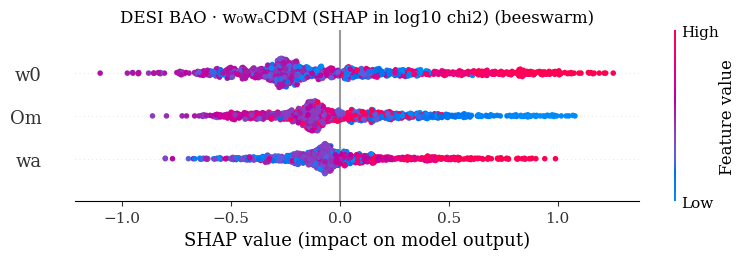

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_bar.png


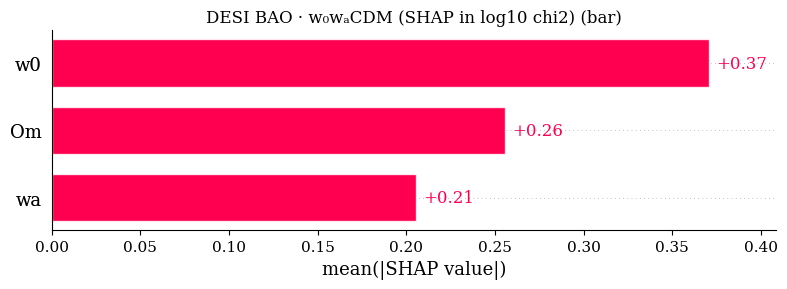

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_waterfall.png


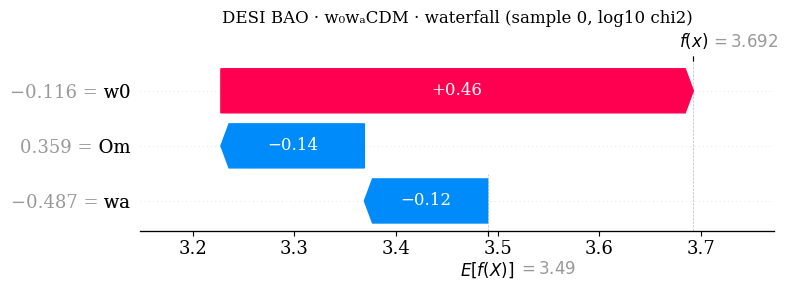

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_Om.png


<Figure size 640x480 with 0 Axes>

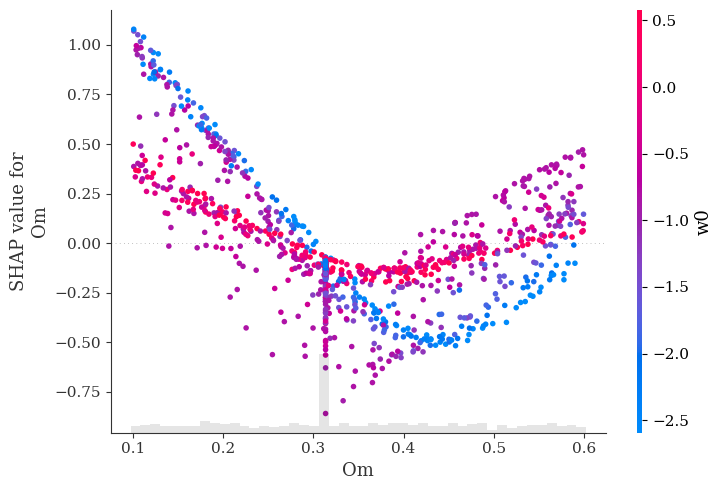

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_w0.png


<Figure size 640x480 with 0 Axes>

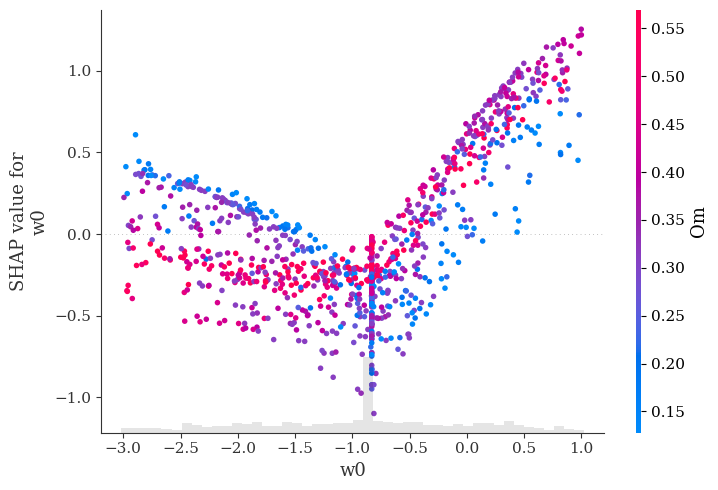

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_wa.png


<Figure size 640x480 with 0 Axes>

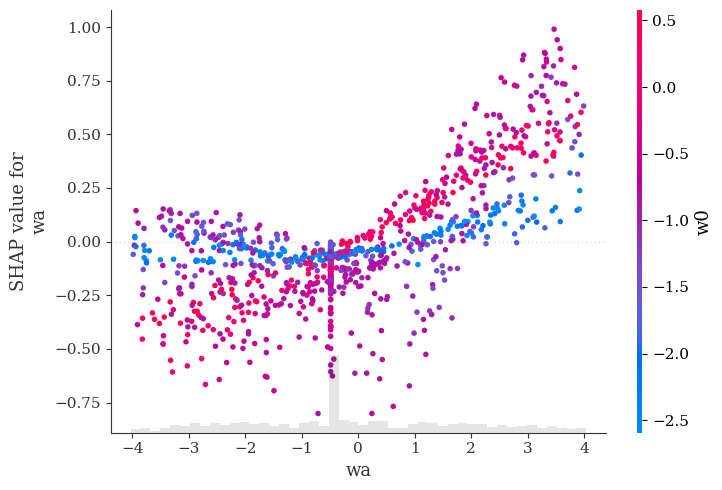

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_3_shap_wa.png')]

In [283]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO · w₀wₐCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO · w₀wₐCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-4"></a>3.4 w0waCDM (z < 2, no Lyman-alpha) — 3D

**Model:** same as 3.3.
**Data:** DESI BAO DR2 with a **z < 2** cut (drops the Lyman-alpha point at z=2.33).
**Purpose:** the Lyman-alpha measurement is the strongest driver of the tension
with LambdaCDM. Removing it widens the contours noticeably.


In [292]:
SECTION = "3_4"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa"]

def chi2_fn(Om, w0, wa):
    return chi2_bao(bao_z2, Om=Om, w0=w0, wa=wa, H0=PLANCK_H0, rd=PLANCK_RD)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0, 0.0])))
_m.limits = [(0.2, 0.42), (-1.6, -0.5), (-2.0, 1.0)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.2097  w0=-0.7894  wa=0.4348
chi2(best-fit) = 6.97


In [293]:
def builder():
    N = 12_000
    pares = [('Om', 'w0'), ('Om', 'wa'), ('w0', 'wa')]
    # Rangos centrados en REF para densidad suficiente cerca del mínimo
    rangos = dict(
        Om=(REF['Om']-0.10, REF['Om']+0.10),
        w0=(REF['w0']-0.55, REF['w0']+0.55),
        wa=(REF['wa']-2.20, REF['wa']+2.20),
    )
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices,
        random_box=dict(Om=(0.1, 0.6), w0=(-3.0, 1.0), wa=(-4.0, 4.0)),
        n_random=25_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Loading cached dataset: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_4_dataset.csv
min chi2 = 7.023


In [294]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  loading cached model: 3_4_model.ubj
  R2=0.99576 | best_iter=950 | n_train=41,650 | n_val=7,350


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_learning_curve.png


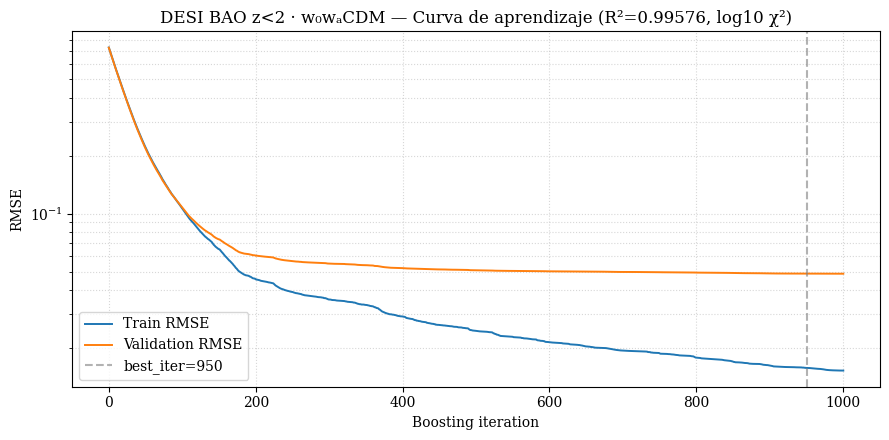

In [295]:
plot_learning_curve(
    info,
    title=f"DESI BAO z<2 · w₀wₐCDM — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_a$ vs $w_0$  ({'Om': 0.20973932679461613}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_w0_wa.png


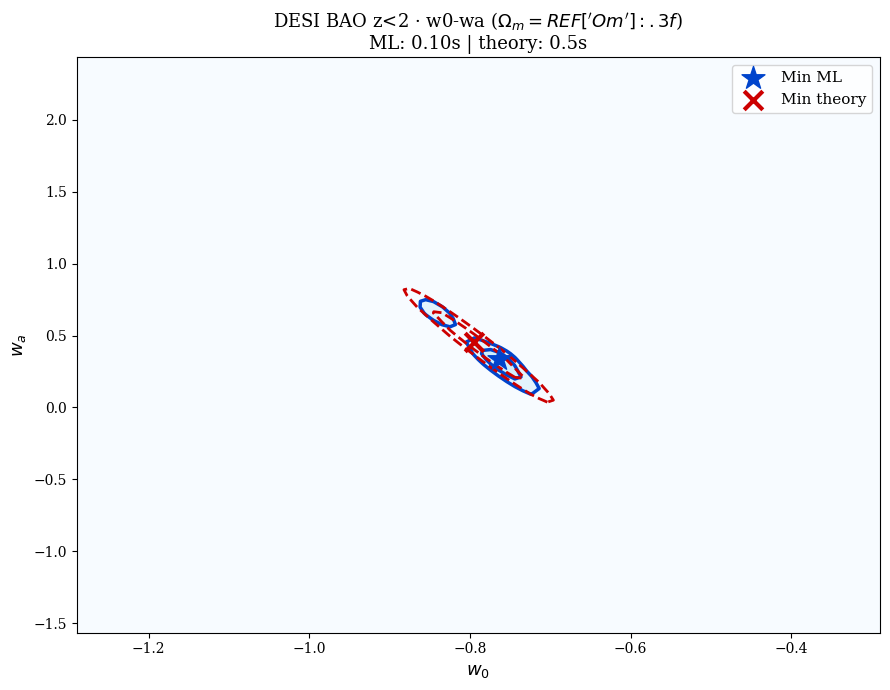

--- $w_0$ vs $\Omega_m$  ({'wa': 0.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_Om_w0.png


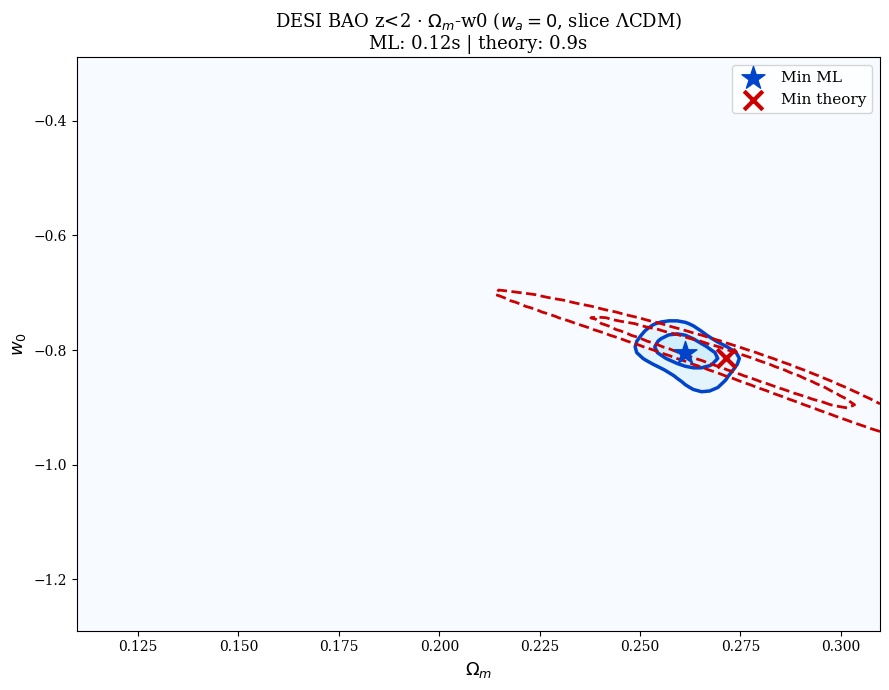

--- $w_a$ vs $\Omega_m$  ({'w0': -1.0}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_Om_wa.png


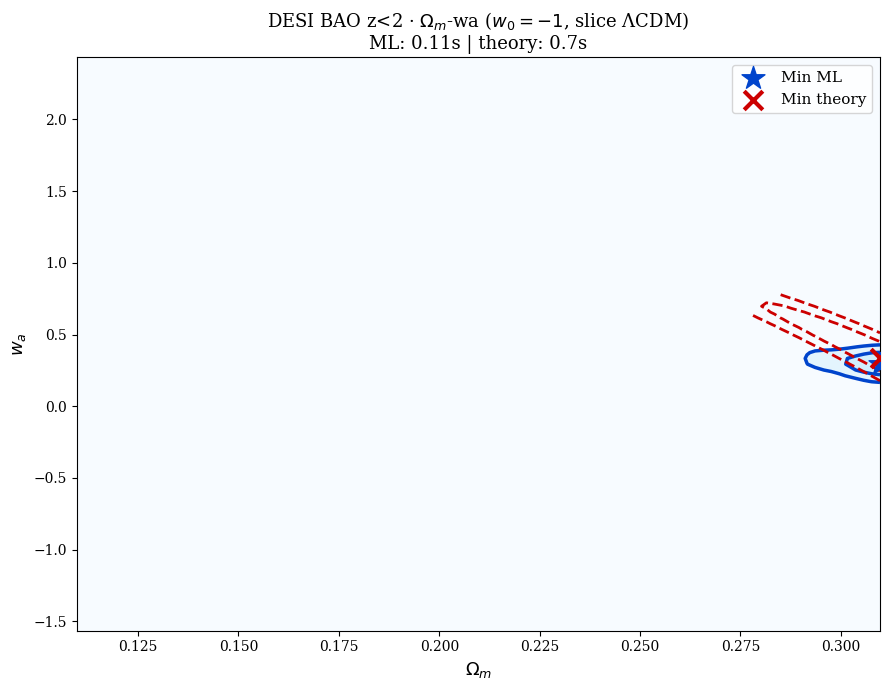

{'Z_ml': array([[13779.991  , 13655.056  , 13408.914  , ...,   499.55603,
           489.30203,   482.791  ],
        [13664.883  , 13542.552  , 13301.011  , ...,   490.3484 ,
           480.16083,   473.7294 ],
        [13453.256  , 13335.262  , 13101.388  , ...,   475.95145,
           465.85654,   459.54715],
        ...,
        [  620.64276,   620.3957 ,   619.59015, ...,  1638.9967 ,
          1643.4613 ,  1645.5818 ],
        [  654.30334,   653.95764,   653.07135, ...,  1711.7144 ,
          1717.205  ,  1719.8595 ],
        [  674.1711 ,   673.7629 ,   672.81683, ...,  1752.4349 ,
          1758.5978 ,  1761.6044 ]], shape=(100, 100), dtype=float32),
 'Z_th': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(100, 100)),
 'time_ml': 0.1131844

In [296]:
common = dict(res=100, sigma=2.0, theory_threshold=30)

plot_contour_2d(
    model, features=FEATURES,
    x_param="w0", y_param="wa",
    x_range=(REF['w0']-0.5, REF['w0']+0.5),
    y_range=(REF['wa']-2.0, REF['wa']+2.0),
    fixed=dict(Om=REF["Om"]),
    theory_fn=chi2_fn,
    title=fr"DESI BAO z<2 · w0-wa ($\Omega_m={{REF['Om']:.3f}}$)",
    x_label=r"$w_0$", y_label=r"$w_a$",
    save_path=FIGURES_DIR / f"{SECTION}_w0_wa.png",
    show=True, **common,
    global_min_chi2=res_opt.fun,
)
plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="w0",
    x_range=(REF['Om']-0.10, REF['Om']+0.10),
    y_range=(REF['w0']-0.50, REF['w0']+0.50),
    fixed=dict(wa=0.0),
    theory_fn=chi2_fn,
    title=r"DESI BAO z<2 · $\Omega_m$-w0 ($w_a=0$, slice ΛCDM)",
    x_label=r"$\Omega_m$", y_label=r"$w_0$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_w0.png",
    show=True, **common,
)
plot_contour_2d(
    model, features=FEATURES,
    x_param="Om", y_param="wa",
    x_range=(REF['Om']-0.10, REF['Om']+0.10),
    y_range=(REF['wa']-2.0,  REF['wa']+2.0),
    fixed=dict(w0=-1.0),
    theory_fn=chi2_fn,
    title=r"DESI BAO z<2 · $\Omega_m$-wa ($w_0=-1$, slice ΛCDM)",
    x_label=r"$\Omega_m$", y_label=r"$w_a$",
    save_path=FIGURES_DIR / f"{SECTION}_Om_wa.png",
    show=True, **common,
)


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_beeswarm.png


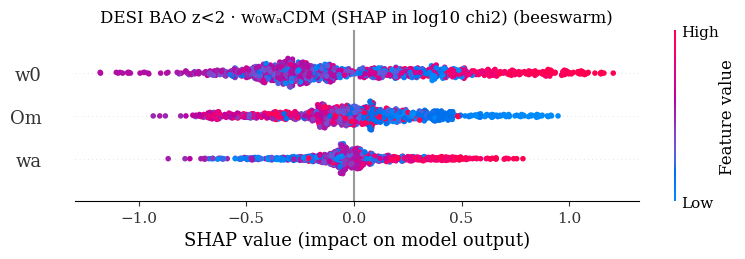

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_bar.png


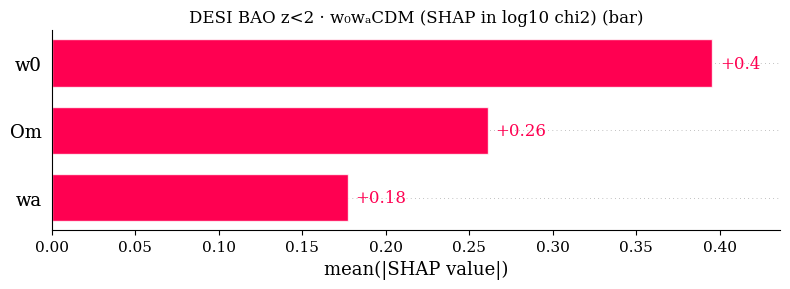

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_waterfall.png


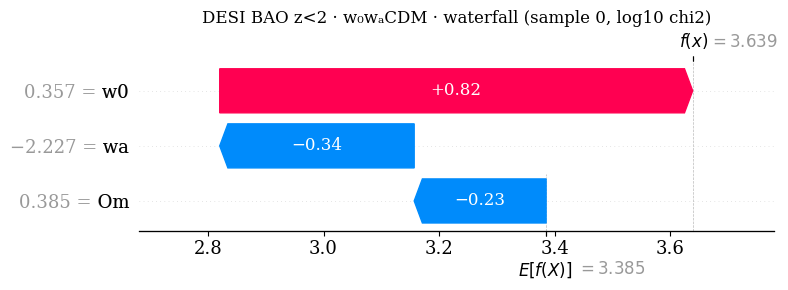

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_Om.png


<Figure size 640x480 with 0 Axes>

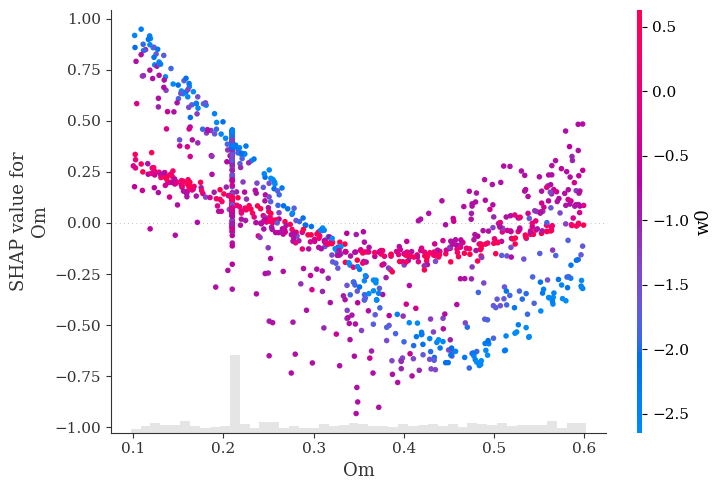

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_w0.png


<Figure size 640x480 with 0 Axes>

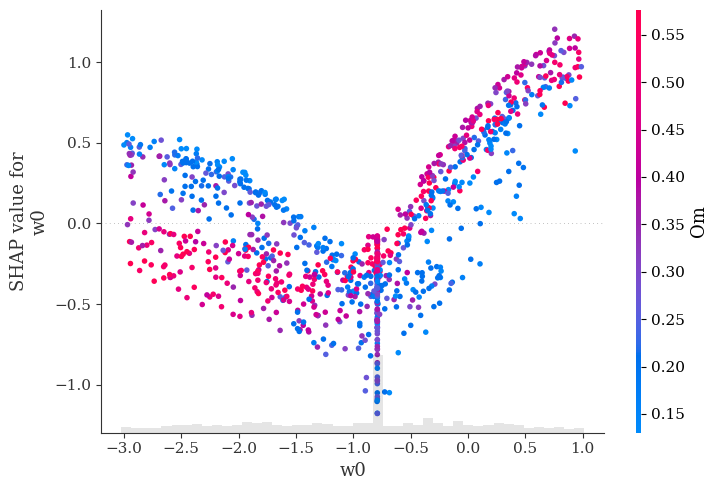

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_wa.png


<Figure size 640x480 with 0 Axes>

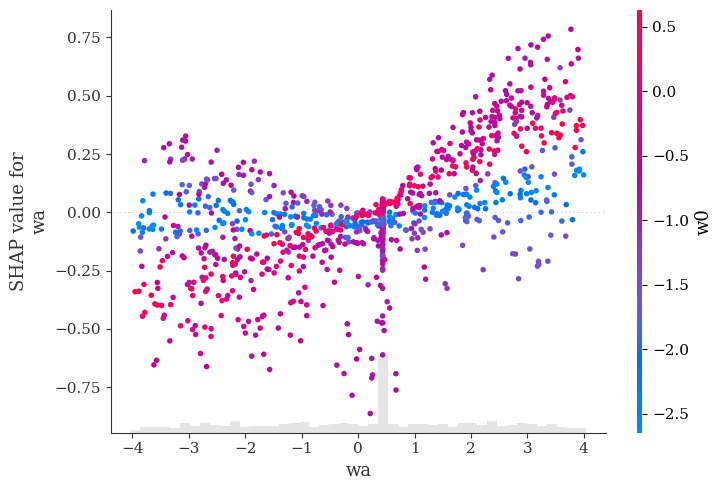

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_4_shap_wa.png')]

In [289]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO z<2 · w₀wₐCDM (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO z<2 · w₀wₐCDM · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-5"></a>3.5 w0waCDM + rd=Planck (H0 free) — 4D

**Model:** `Flatw0waCDM` 4D (Om, w0, wa, H0). rd fixed at Planck (147.09 Mpc).
**Data:** DESI BAO DR2.
**Purpose:** explore how H0 degenerates with the other parameters when rd is
set by early-universe physics. Without external priors, BAO cannot fix H0 by
itself when rd is fixed, so H0 contours are wide.


In [250]:
SECTION = "3_5"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0"]

def chi2_fn(Om, w0, wa, H0):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=PLANCK_RD)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0, 0.0, 67.36])))
_m.limits = [(0.2, 0.42), (-1.6, -0.5), (-2.0, 1.0), (55, 85)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}  H0={REF['H0']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3526  w0=-0.5000  wa=-1.6149  H0=64.4179
chi2(best-fit) = 6.21


In [251]:
def builder():
    N = 7_000
    pares = [('Om','w0'), ('Om','wa'), ('Om','H0'),
             ('w0','wa'), ('w0','H0'), ('wa','H0')]
    rangos = dict(Om=(0.1, 0.6), w0=(-2.5, 0.5), wa=(-4.0, 3.0), H0=(55, 85))
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=0,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_5_dataset.csv)
Evaluating chi2 at 42000 points across 11 cores...
     2000/42000 (  4.8%) | elapsed    4.9s | ETA   98.0s |    408 pts/s
     4000/42000 (  9.5%) | elapsed    5.2s | ETA   49.2s |    772 pts/s
     6000/42000 ( 14.3%) | elapsed    5.9s | ETA   35.7s |   1009 pts/s
     8000/42000 ( 19.0%) | elapsed    6.5s | ETA   27.7s |   1227 pts/s
    10000/42000 ( 23.8%) | elapsed    7.2s | ETA   23.1s |   1385 pts/s
    12000/42000 ( 28.6%) | elapsed    7.9s | ETA   19.8s |   1517 pts/s
    14000/42000 ( 33.3%) | elapsed    8.6s | ETA   17.1s |   1635 pts/s
    16000/42000 ( 38.1%) | elapsed    9.2s | ETA   15.0s |   1733 pts/s
    18000/42000 ( 42.9%) | elapsed   10.1s | ETA   13.4s |   1785 pts/s
    20000/42000 ( 47.6%) | elapsed   10.6s | ETA   11.6s |   1892 pts/s
    22000/42000 ( 52.4%) | elapsed   11.3s | ETA   10.3s |   1940 pts/s
    24000/42000 ( 57.1%) | elapsed   12.0s | ETA    9.0s |  

In [252]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  dropping 8 rows with chi2 >= 90000.0 (sentinels)
  target in shifted-log10: range [0.000, 4.952]
  training: 172.33s | R2=0.99765 | best_iter=1028/3000  (early stop, ~66% saved)
  model cached: 3_5_model.ubj


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_learning_curve.png


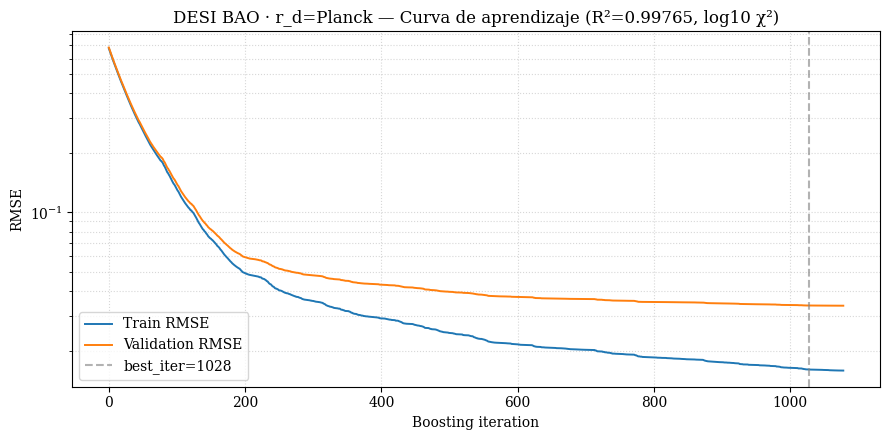

In [253]:
plot_learning_curve(
    info,
    title=f"DESI BAO · r_d=Planck — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': -1.61492876725888, 'H0': 64.41791951072922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_Om_w0.png


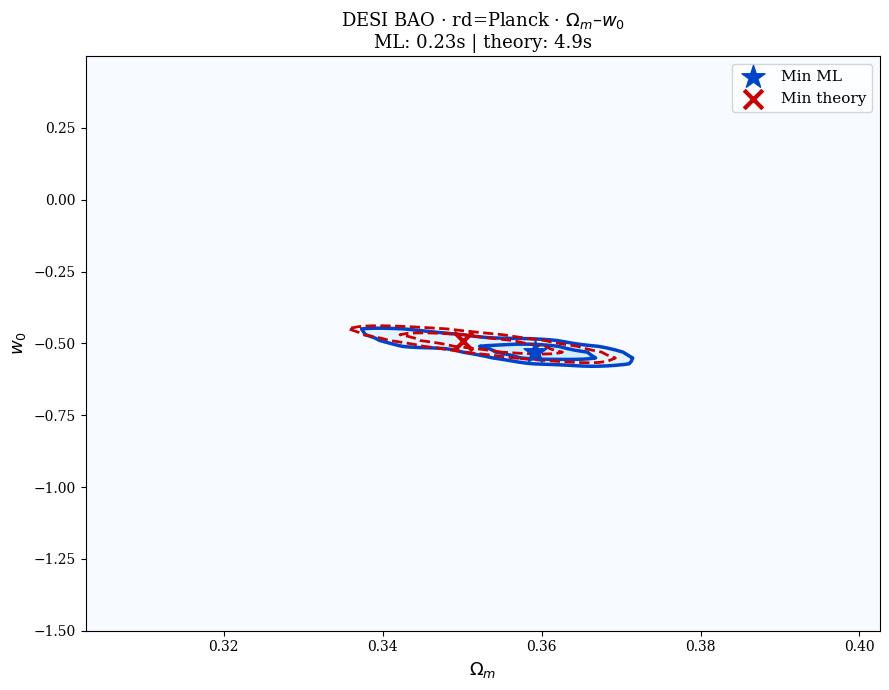

--- $w_a$ vs $\Omega_m$  ({'w0': -0.5000031459728641, 'H0': 64.41791951072922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_Om_wa.png


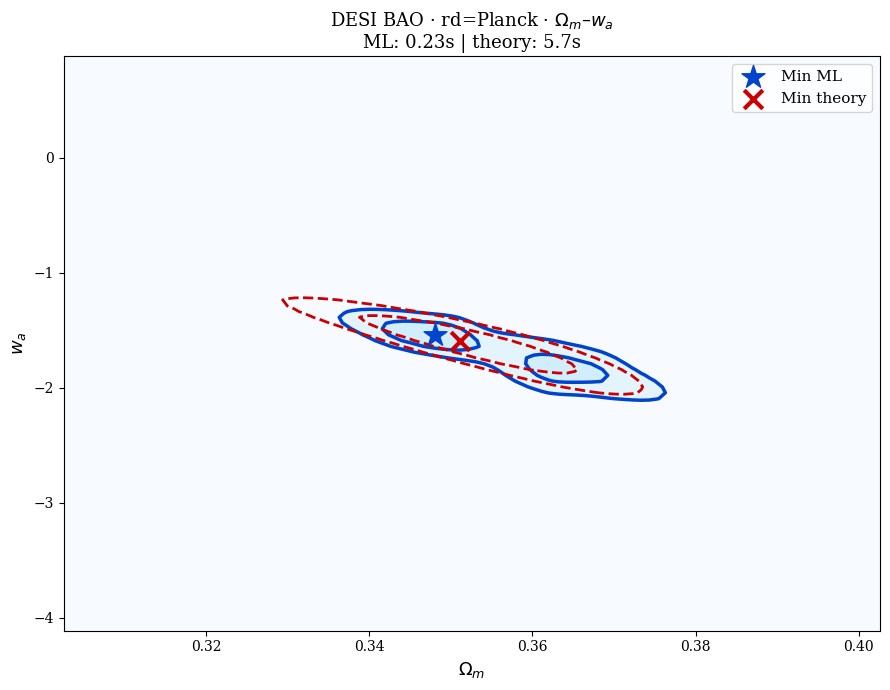

--- $H_0$ vs $\Omega_m$  ({'w0': -0.5000031459728641, 'wa': -1.61492876725888}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_Om_H0.png


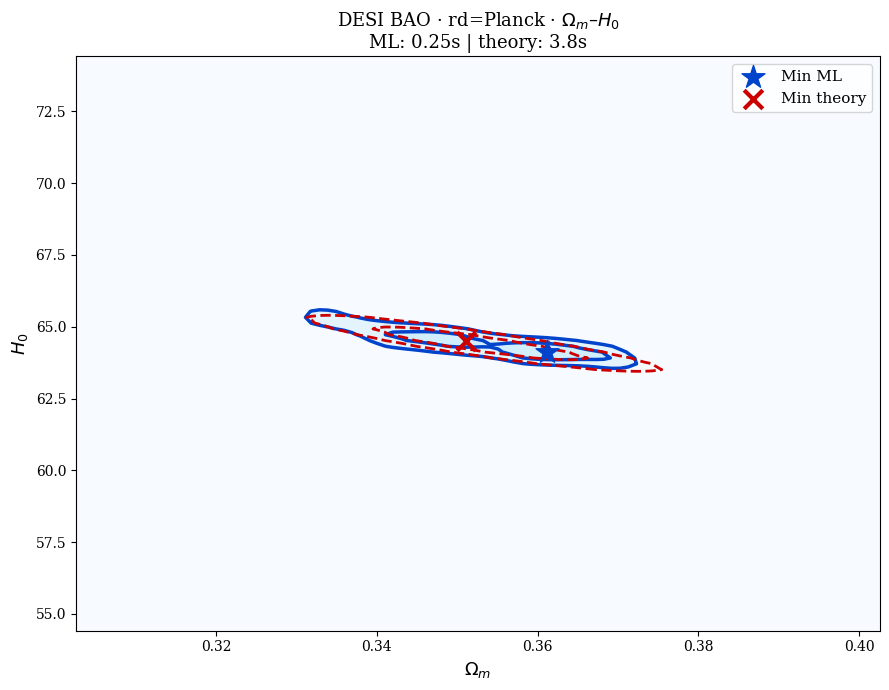

--- $w_a$ vs $w_0$  ({'Om': 0.35258697317758747, 'H0': 64.41791951072922}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_w0_wa.png


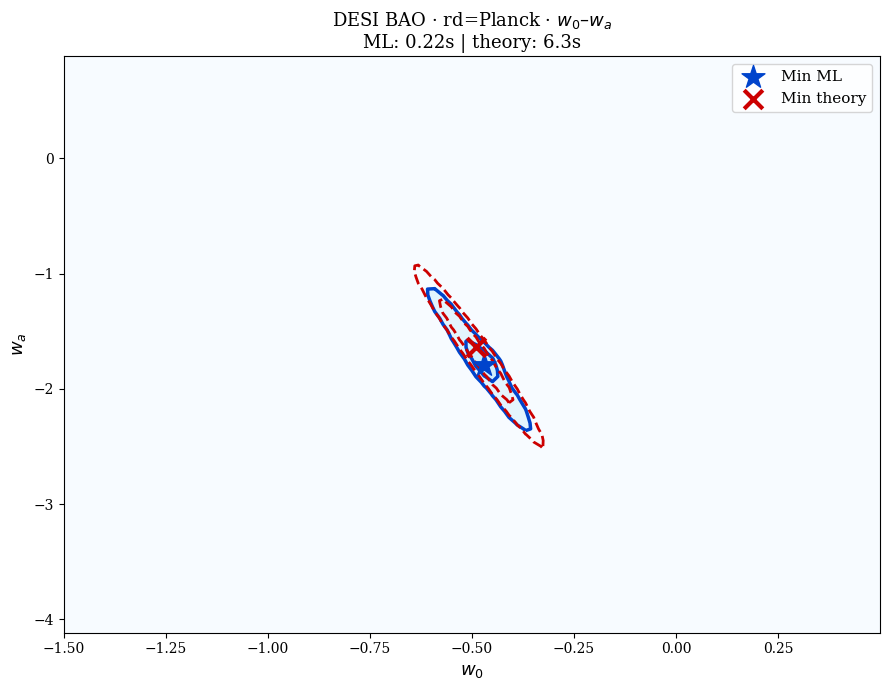

--- $H_0$ vs $w_0$  ({'Om': 0.35258697317758747, 'wa': -1.61492876725888}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_w0_H0.png


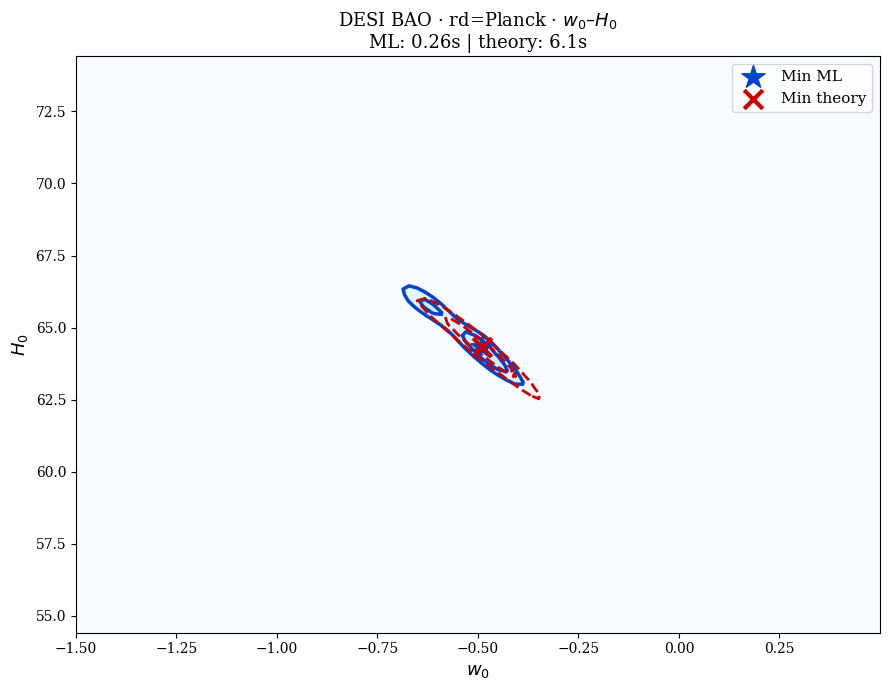

--- $H_0$ vs $w_a$  ({'Om': 0.35258697317758747, 'w0': -0.5000031459728641}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_wa_H0.png


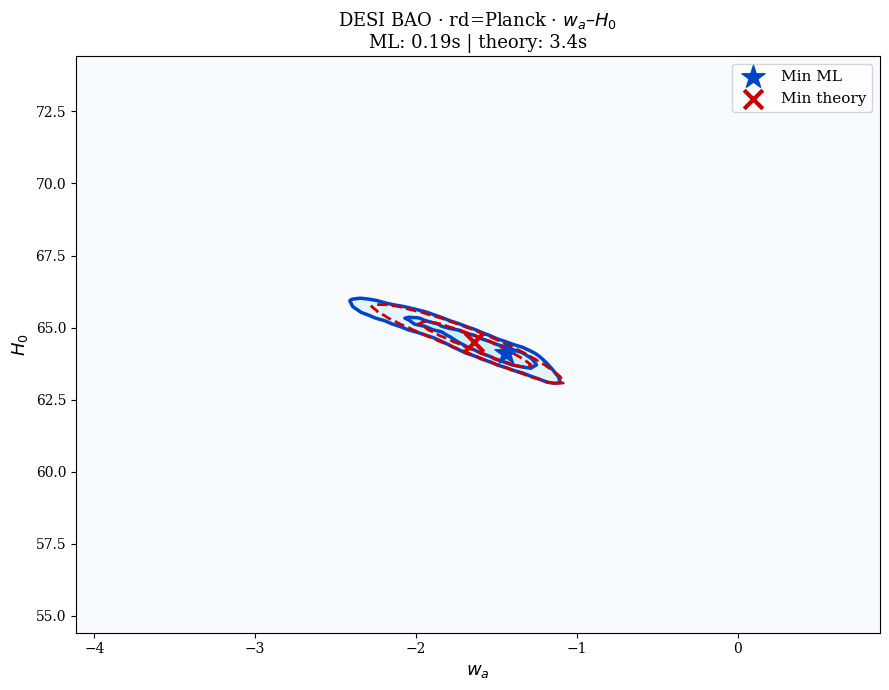

In [254]:
common = dict(res=100, sigma=2.0, theory_threshold=50)
RANGES = dict(
    Om=(REF['Om'] - 0.05, REF['Om'] + 0.05),
    w0=(REF['w0'] - 1.0,  REF['w0'] + 1.0),
    wa=(REF['wa'] - 2.5,  REF['wa'] + 2.5),
    H0=(REF['H0'] - 10,   REF['H0'] + 10),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0=r"$H_0$")

for x, y in [('Om','w0'), ('Om','wa'), ('Om','H0'),
             ('w0','wa'), ('w0','H0'), ('wa','H0')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DESI BAO · rd=Planck · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_beeswarm.png


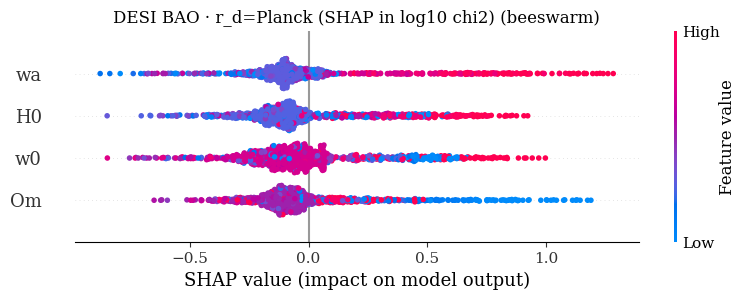

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_bar.png


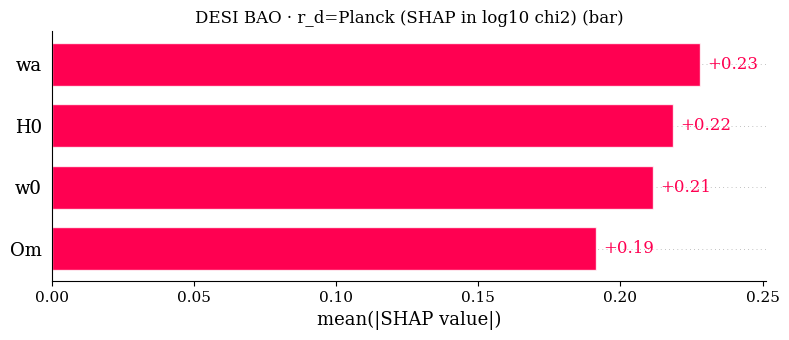

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_waterfall.png


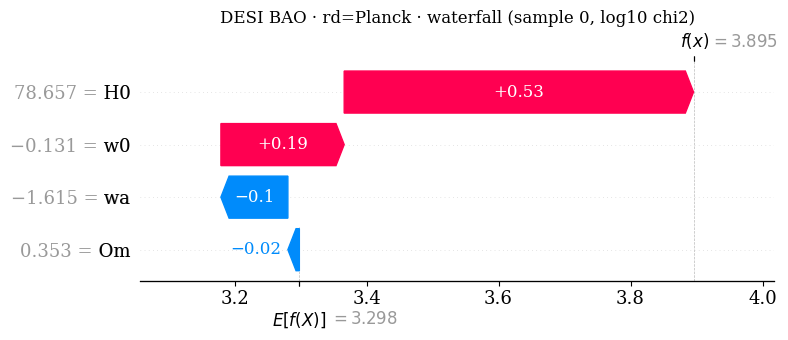

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_Om.png


<Figure size 640x480 with 0 Axes>

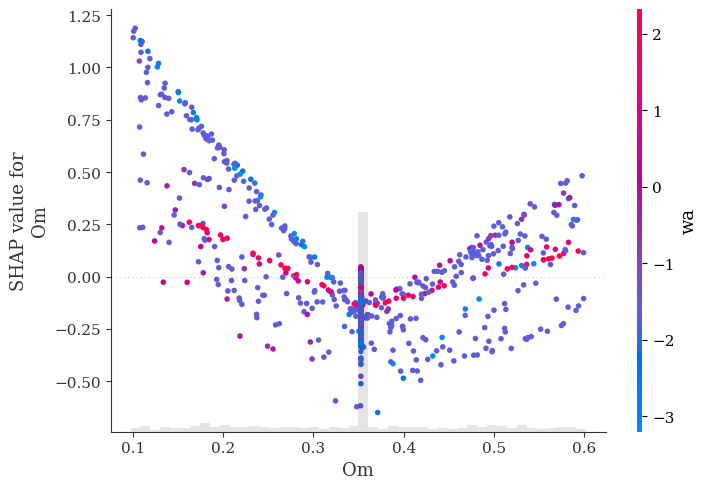

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_w0.png


<Figure size 640x480 with 0 Axes>

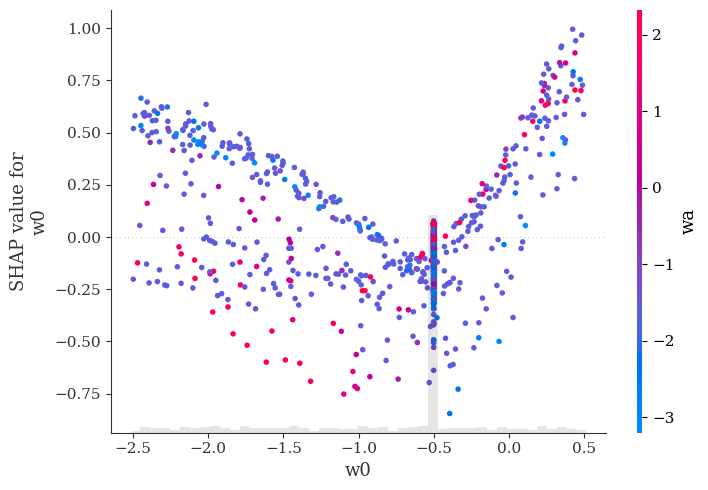

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_wa.png


<Figure size 640x480 with 0 Axes>

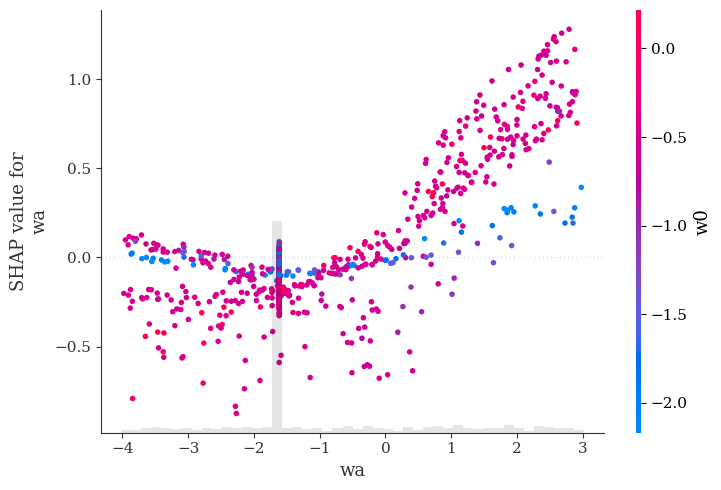

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_H0.png


<Figure size 640x480 with 0 Axes>

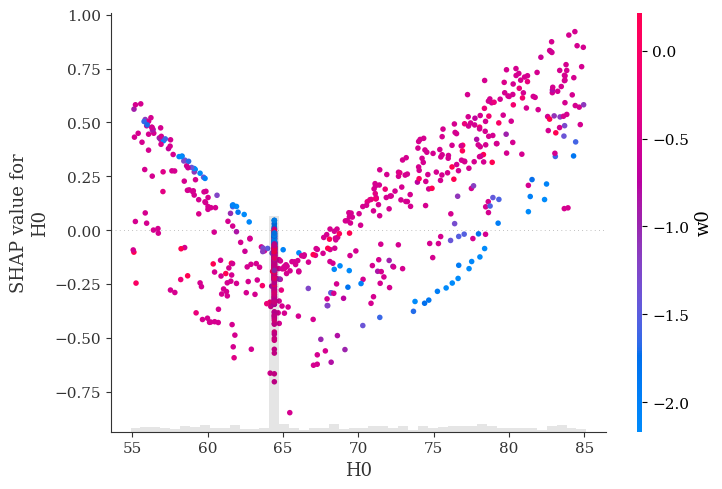

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_5_shap_H0.png')]

In [255]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO · r_d=Planck (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO · rd=Planck · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-6"></a>3.6 w0waCDM with H0*rd (BAO-only) — 4D

**Model:** `Flatw0waCDM` 4D (Om, w0, wa, H0*rd).
**Data:** DESI BAO DR2.
**Purpose:** the BAO chi2 depends **only on the product H0*rd**, not on each
separately. The BAO distance ratios all factor as DM/rd = (c / (H0*rd)) * I(z),
and similarly for DH/rd and DV/rd. So H0*rd is the natural BAO observable.

In `chi2_bao` this maps to `H0=H0_rd, rd=1.0`.


In [256]:
SECTION = "3_6"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0_rd"]
H0_rd_PLANCK = PLANCK_H0 * PLANCK_RD
print(f"H0*rd Planck = {H0_rd_PLANCK:.1f}")

def chi2_fn(Om, w0, wa, H0_rd):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0_rd, rd=1.0)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.315, -1.0, 0.0, 9907.0])))
_m.limits = [(0.2, 0.42), (-1.6, -0.5), (-2.0, 1.0), (8500, 11500)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}  H0_rd={REF['H0_rd']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


H0*rd Planck = 9908.0
Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3525  w0=-0.5000  wa=-1.6141  H0_rd=9475.4910
chi2(best-fit) = 6.21


In [257]:
def builder():
    N = 5_000
    pares = [('Om','w0'), ('Om','wa'), ('Om','H0_rd'),
             ('w0','wa'), ('w0','H0_rd'), ('wa','H0_rd')]
    rangos = dict(Om=(0.1, 0.6), w0=(-2.5, 0.5), wa=(-4.0, 3.0), H0_rd=(8500, 11500))
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=10000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_6_dataset.csv)
Evaluating chi2 at 30000 points across 11 cores...
     2000/30000 (  6.7%) | elapsed    5.4s | ETA   75.6s |    370 pts/s
     4000/30000 ( 13.3%) | elapsed    6.0s | ETA   39.1s |    665 pts/s
     6000/30000 ( 20.0%) | elapsed    6.8s | ETA   27.3s |    878 pts/s
     8000/30000 ( 26.7%) | elapsed    7.5s | ETA   20.6s |   1067 pts/s
    10000/30000 ( 33.3%) | elapsed    8.1s | ETA   16.3s |   1228 pts/s
    12000/30000 ( 40.0%) | elapsed    9.0s | ETA   13.5s |   1336 pts/s
    14000/30000 ( 46.7%) | elapsed    9.6s | ETA   11.0s |   1454 pts/s
    16000/30000 ( 53.3%) | elapsed   10.4s | ETA    9.1s |   1544 pts/s
    18000/30000 ( 60.0%) | elapsed   11.1s | ETA    7.4s |   1620 pts/s
    20000/30000 ( 66.7%) | elapsed   11.9s | ETA    5.9s |   1688 pts/s
    22000/30000 ( 73.3%) | elapsed   12.7s | ETA    4.6s |   1739 pts/s
    24000/30000 ( 80.0%) | elapsed   13.4s | ETA    3.4s |  

In [258]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  dropping 6 rows with chi2 >= 90000.0 (sentinels)
  target in shifted-log10: range [0.000, 4.944]
  training: 224.01s | R2=0.99759 | best_iter=1395/3000  (early stop, ~53% saved)
  model cached: 3_6_model.ubj


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_learning_curve.png


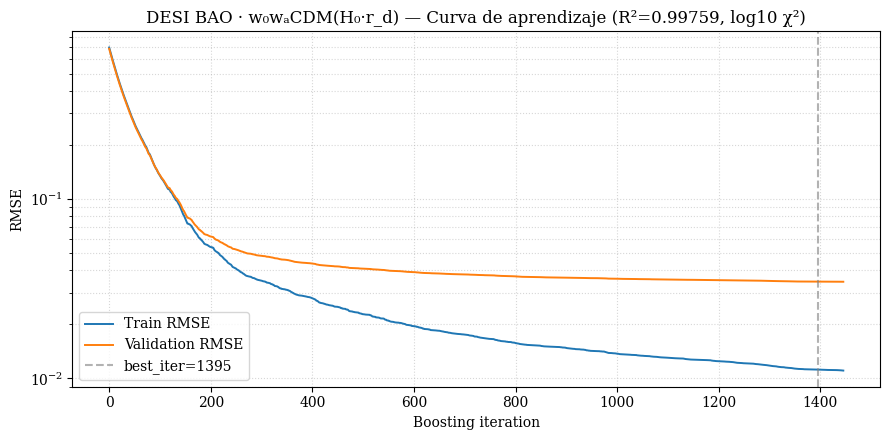

In [259]:
plot_learning_curve(
    info,
    title=f"DESI BAO · w₀wₐCDM(H₀·r_d) — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': -1.614135173430772, 'H0_rd': 9475.491048733724}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_Om_w0.png


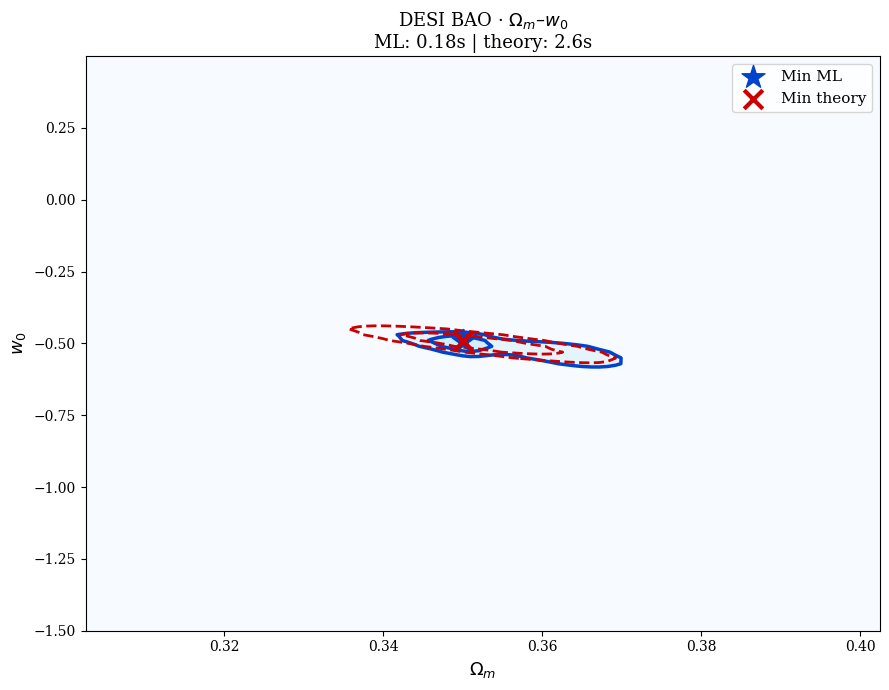

--- $w_a$ vs $\Omega_m$  ({'w0': -0.5000299029519061, 'H0_rd': 9475.491048733724}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_Om_wa.png


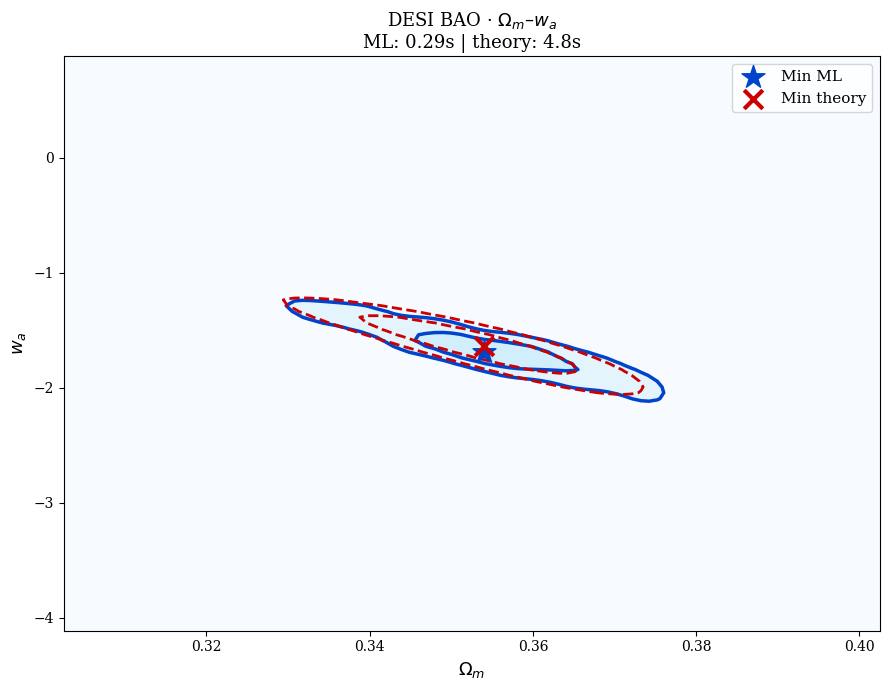

--- $H_0 \cdot r_d$ vs $\Omega_m$  ({'w0': -0.5000299029519061, 'wa': -1.614135173430772}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_Om_H0_rd.png


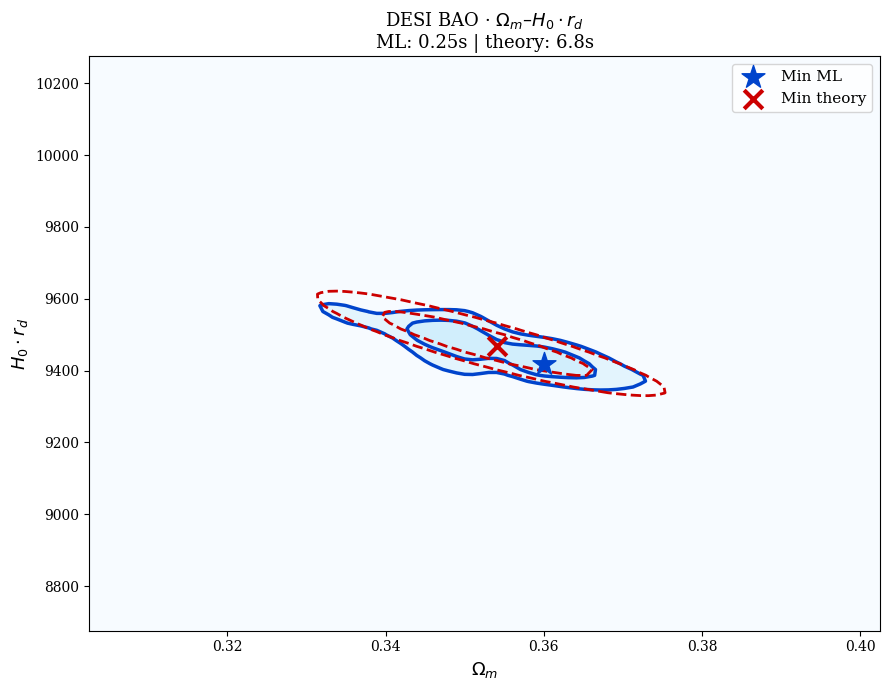

--- $w_a$ vs $w_0$  ({'Om': 0.35251850406437224, 'H0_rd': 9475.491048733724}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_w0_wa.png


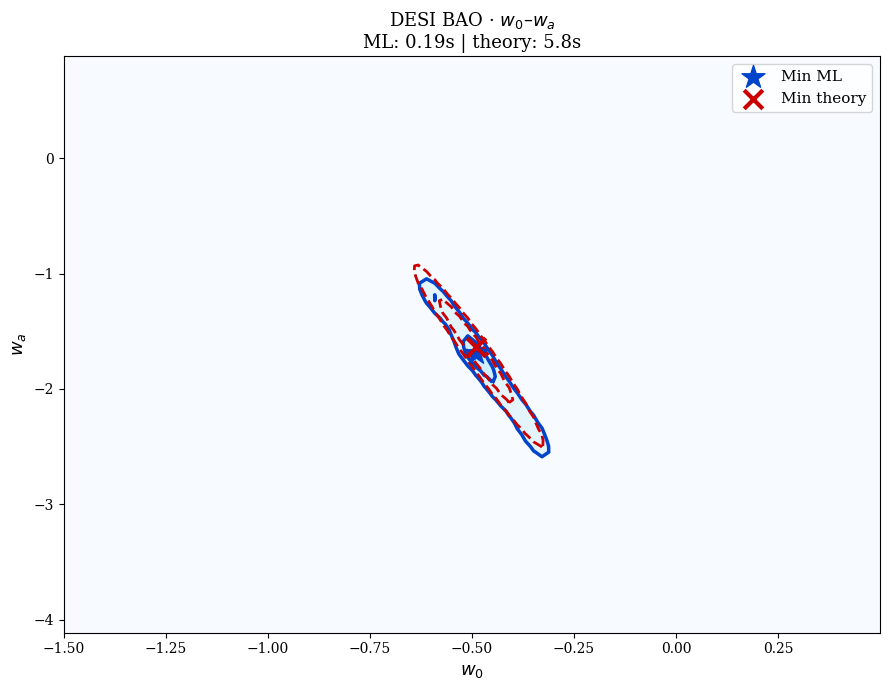

--- $H_0 \cdot r_d$ vs $w_0$  ({'Om': 0.35251850406437224, 'wa': -1.614135173430772}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_w0_H0_rd.png


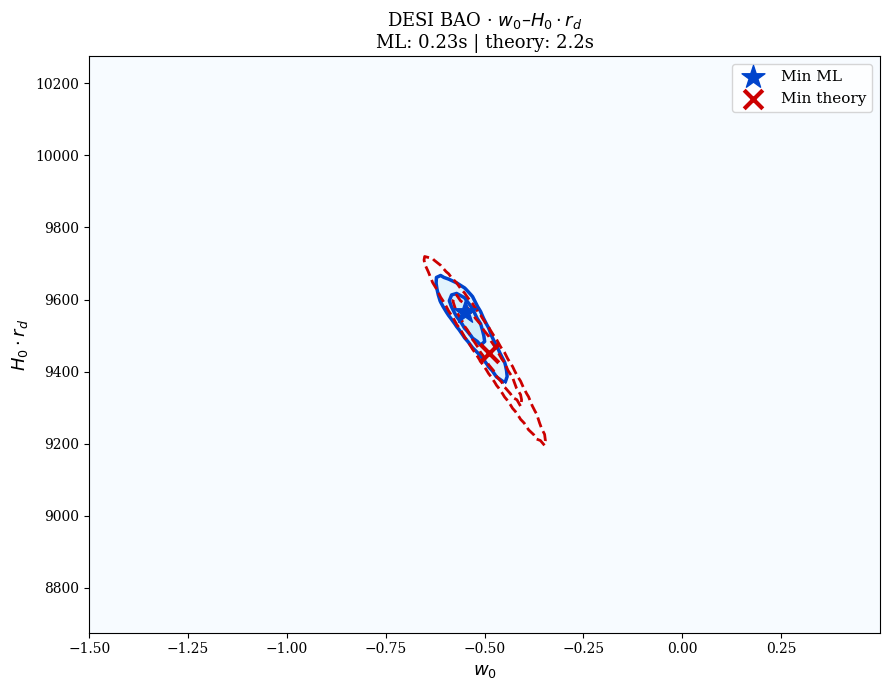

--- $H_0 \cdot r_d$ vs $w_a$  ({'Om': 0.35251850406437224, 'w0': -0.5000299029519061}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_wa_H0_rd.png


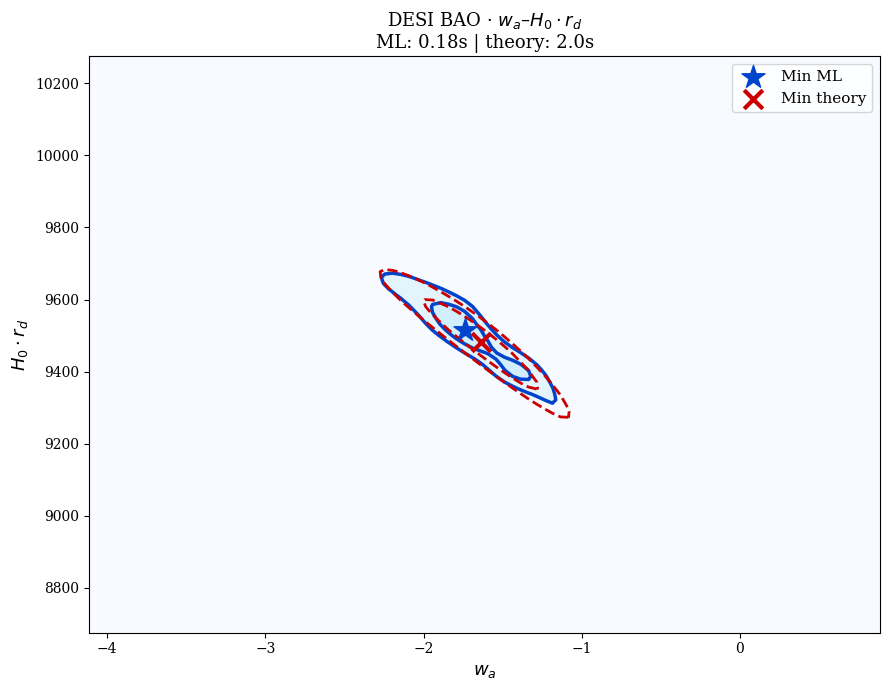

In [260]:
common = dict(res=100, sigma=2.0, theory_threshold=50)
RANGES = dict(
    Om=(REF['Om']    - 0.05,    REF['Om']    + 0.05),
    w0=(REF['w0']    - 1.0,     REF['w0']    + 1.0),
    wa=(REF['wa']    - 2.5,     REF['wa']    + 2.5),
    H0_rd=(REF['H0_rd'] - 800,  REF['H0_rd'] + 800),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0_rd=r"$H_0 \cdot r_d$")

for x, y in [('Om','w0'), ('Om','wa'), ('Om','H0_rd'),
             ('w0','wa'), ('w0','H0_rd'), ('wa','H0_rd')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"DESI BAO · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_beeswarm.png


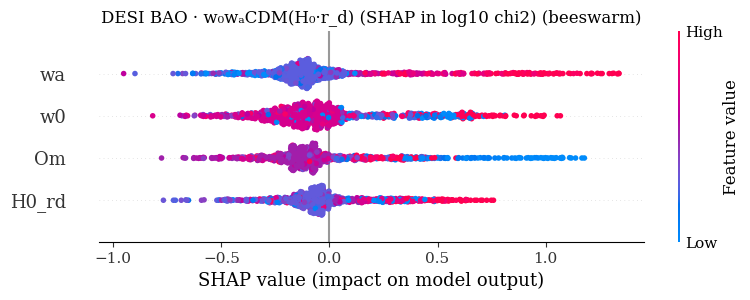

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_bar.png


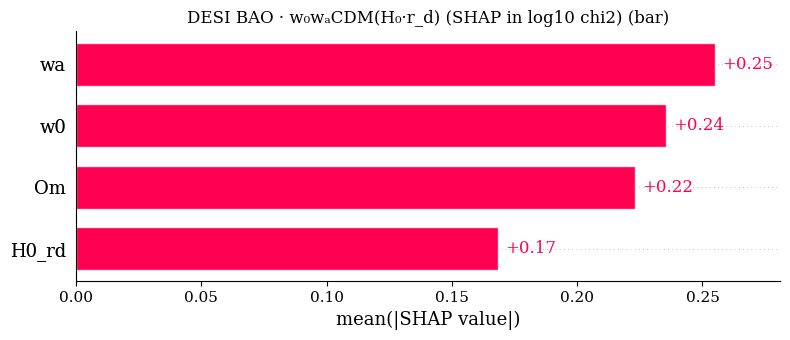

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_waterfall.png


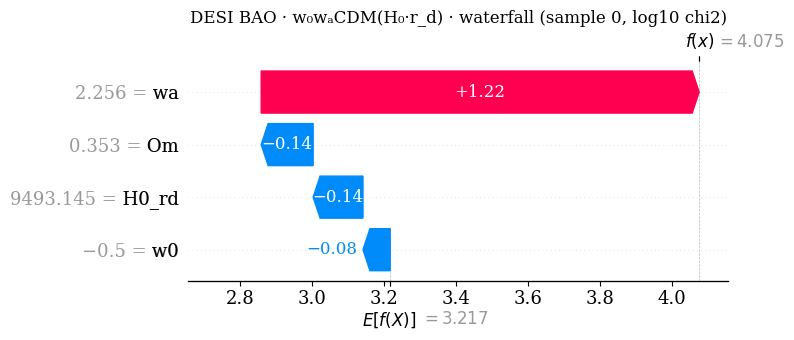

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_Om.png


<Figure size 640x480 with 0 Axes>

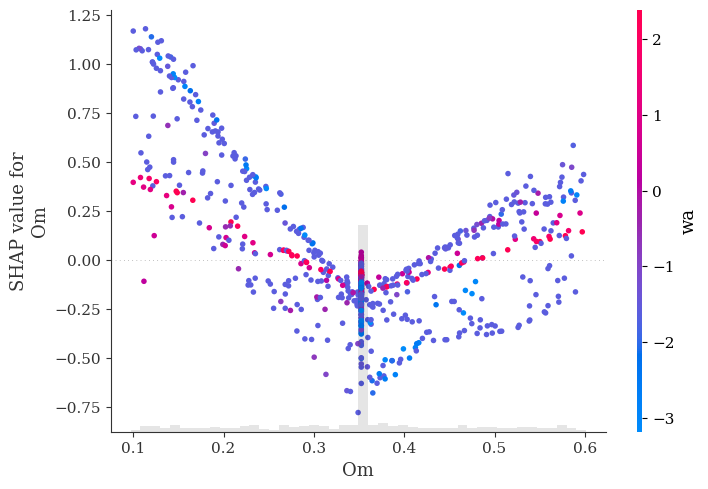

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_w0.png


<Figure size 640x480 with 0 Axes>

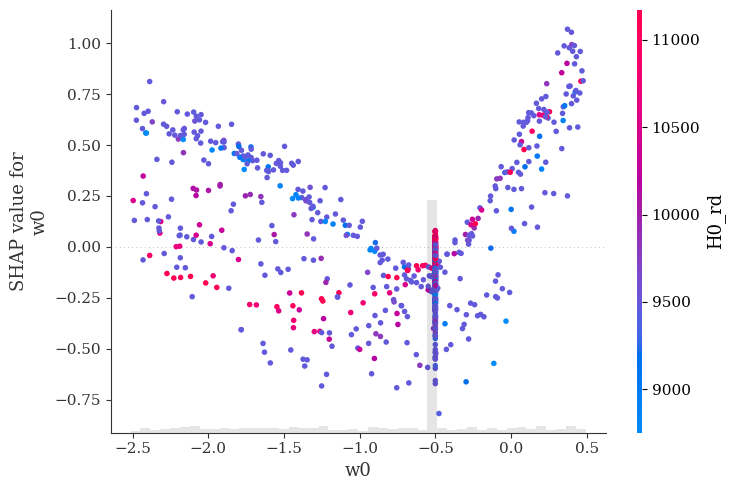

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_wa.png


<Figure size 640x480 with 0 Axes>

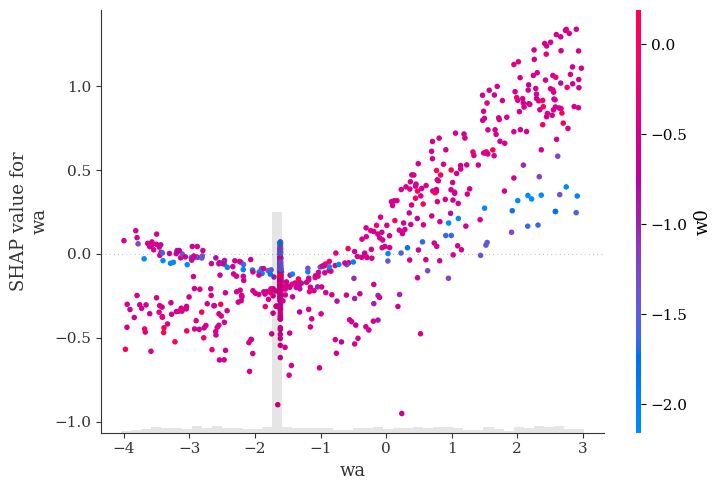

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_H0_rd.png


<Figure size 640x480 with 0 Axes>

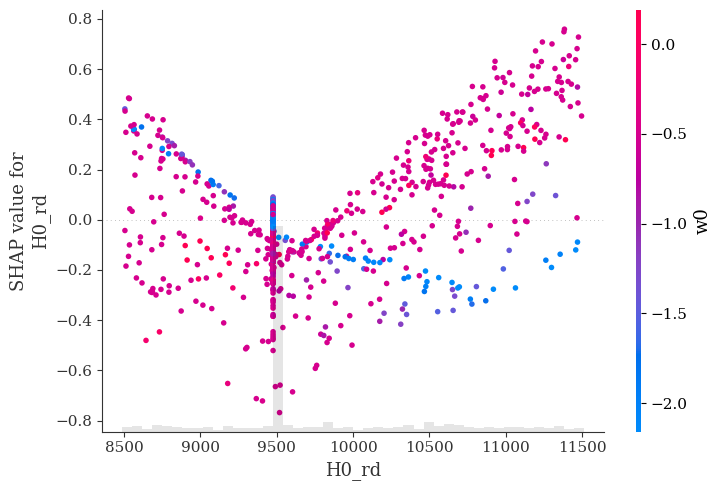

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_6_shap_H0_rd.png')]

In [261]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="DESI BAO · w₀wₐCDM(H₀·r_d) (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="DESI BAO · w₀wₐCDM(H₀·r_d) · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-7"></a>3.7 H0–rd degeneracy (SHAP) — 5D without priors

**Model:** `Flatw0waCDM` 5D (Om, w0, wa, H0, rd).
**Data:** DESI BAO DR2; 40k random points, no slices, no priors.
**Purpose:** show visually with SHAP that BAO **does not constrain H0 and rd
separately**, only the product H0*rd (the analytical demonstration is in 3.6).
Expected SHAP reading:
- Importance of Om, w0, wa: **high** (the data constrains them).
- Importance of H0 and rd alone: **low**, with strong anti-correlation in the
  dependence plots (the degeneracy fingerprint).

No contours — the goal here is the SHAP reading of the degeneracy.


In [262]:
SECTION = "3_7"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0", "rd"]

def chi2_fn(Om, w0, wa, H0, rd):
    return chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=rd)

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3153, -1.0, 0.0, 67.36, 147.09])))
_m.limits = [(0.2, 0.42), (-1.6, -0.5), (-2.0, 1.0), (55, 85), (130, 165)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}  H0={REF['H0']:.4f}  rd={REF['rd']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3526  w0=-0.5000  wa=-1.6164  H0=65.8578  rd=143.8848
chi2(best-fit) = 6.21


In [263]:
def builder():
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        random_box=dict(
            Om=(0.20, 0.40), w0=(-1.5, -0.5), wa=(-1.5, 1.0),
            H0=(60, 75), rd=(140, 155),
        ),
        n_random=40_000,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_7_dataset.csv)
Evaluating chi2 at 40000 points across 11 cores...
     2000/40000 (  5.0%) | elapsed    0.6s | ETA   11.6s |   3286 pts/s
     4000/40000 ( 10.0%) | elapsed    0.8s | ETA    7.2s |   5022 pts/s
     6000/40000 ( 15.0%) | elapsed    1.0s | ETA    5.7s |   6014 pts/s
     8000/40000 ( 20.0%) | elapsed    1.2s | ETA    4.6s |   6939 pts/s
    10000/40000 ( 25.0%) | elapsed    1.4s | ETA    4.1s |   7384 pts/s
    12000/40000 ( 30.0%) | elapsed    1.5s | ETA    3.5s |   7905 pts/s
    14000/40000 ( 35.0%) | elapsed    1.7s | ETA    3.2s |   8176 pts/s
    16000/40000 ( 40.0%) | elapsed    1.9s | ETA    2.8s |   8520 pts/s
    18000/40000 ( 45.0%) | elapsed    2.1s | ETA    2.5s |   8640 pts/s
    20000/40000 ( 50.0%) | elapsed    2.3s | ETA    2.3s |   8854 pts/s
    22000/40000 ( 55.0%) | elapsed    2.4s | ETA    2.0s |   9033 pts/s
    24000/40000 ( 60.0%) | elapsed    2.6s | ETA    1.8s |  

  target in shifted-log10: range [0.000, 4.447]
  training: 99.55s | R2=0.93748 | best_iter=740/3000  (early stop, ~75% saved)
  model cached: 3_7_model.ubj
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_learning_curve.png


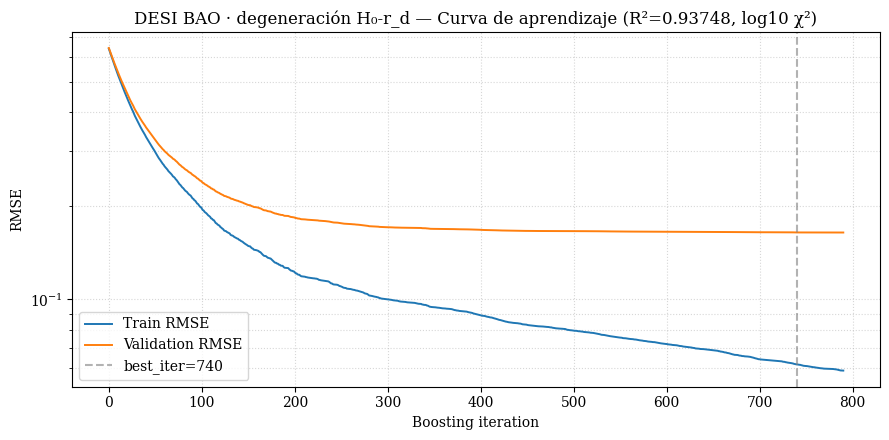

In [264]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)
plot_learning_curve(
    info,
    title=f"DESI BAO · degeneración H₀-r_d — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

### Reading the degeneracy

The **bar** plot ranks features by mean |SHAP|. Expect w0, wa and Om above H0
and rd taken separately.

The **dependence** plots of H0 and rd should show high color dispersion
(strong interaction with the other parameter) — the H0*rd degeneracy signature.


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_beeswarm.png


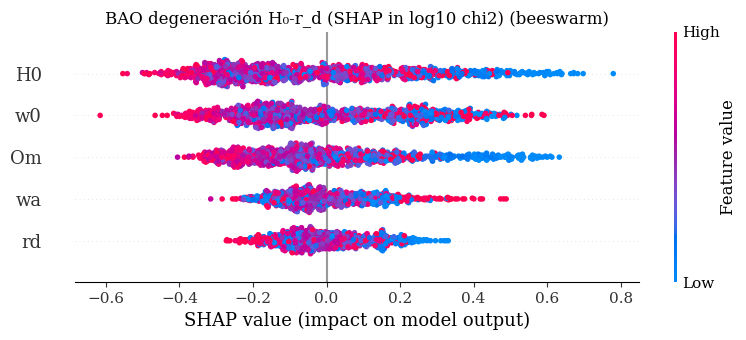

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_bar.png


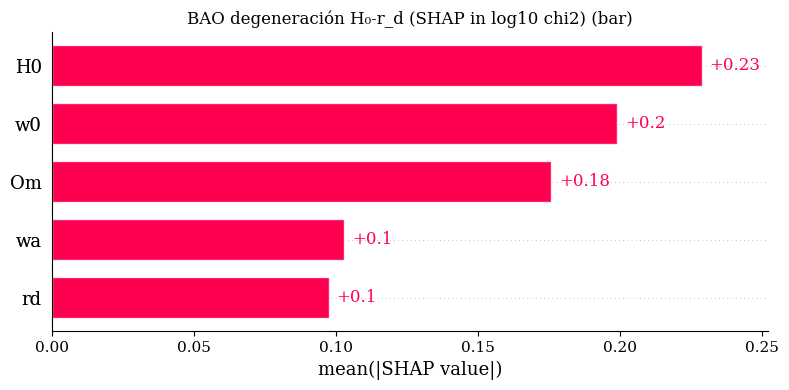

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_waterfall.png


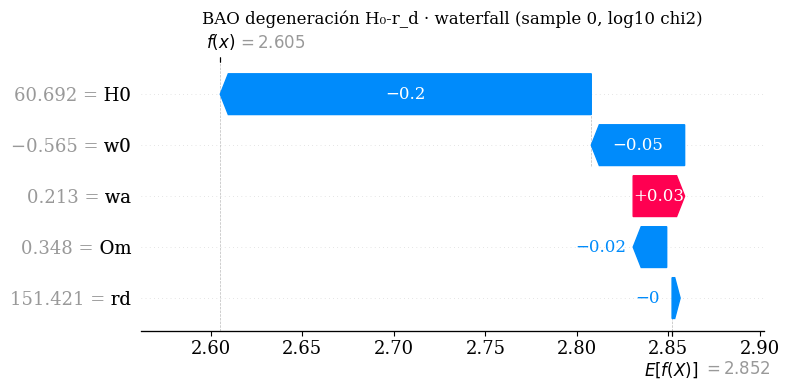

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_Om.png


<Figure size 640x480 with 0 Axes>

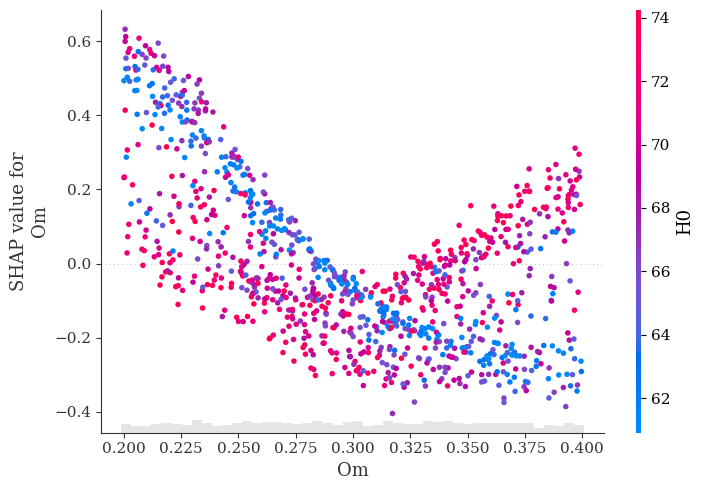

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_w0.png


<Figure size 640x480 with 0 Axes>

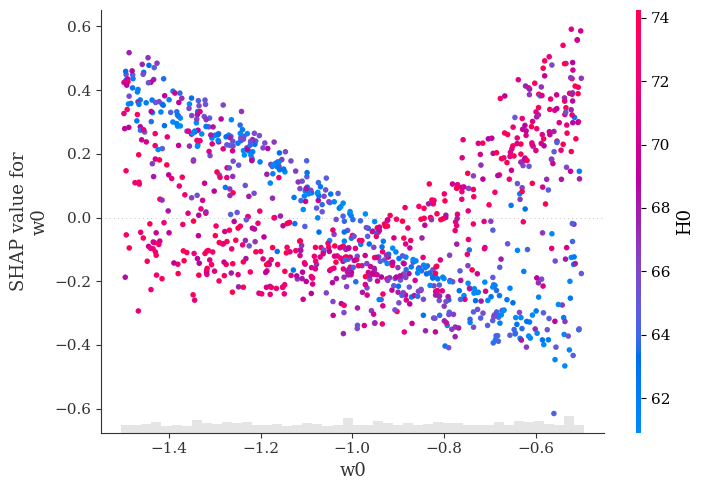

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_wa.png


<Figure size 640x480 with 0 Axes>

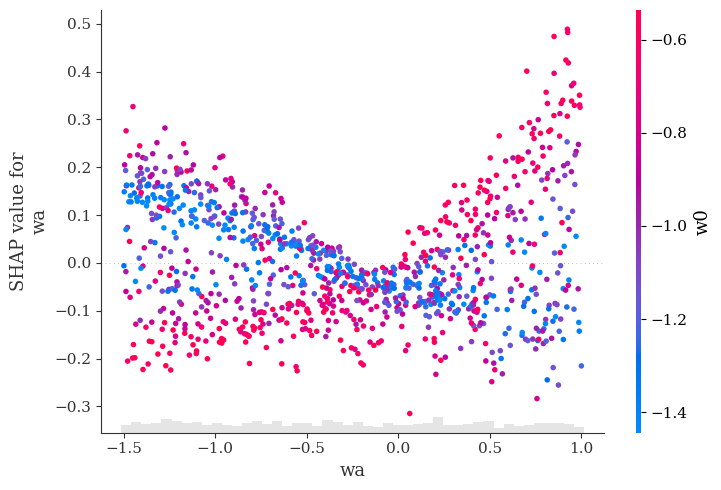

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_H0.png


<Figure size 640x480 with 0 Axes>

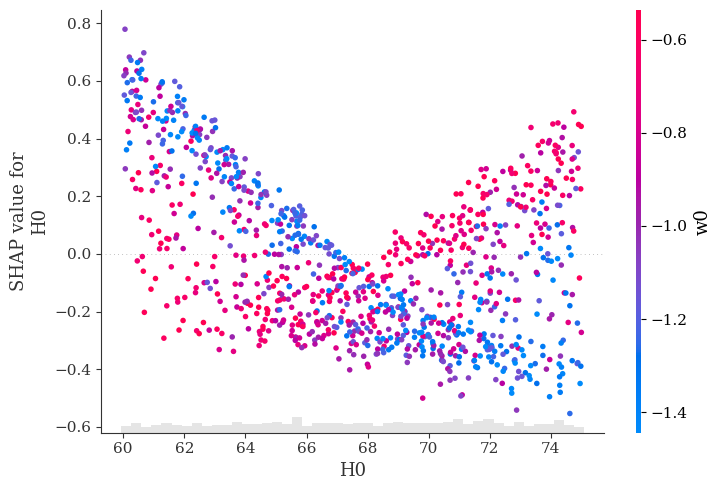

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_rd.png


<Figure size 640x480 with 0 Axes>

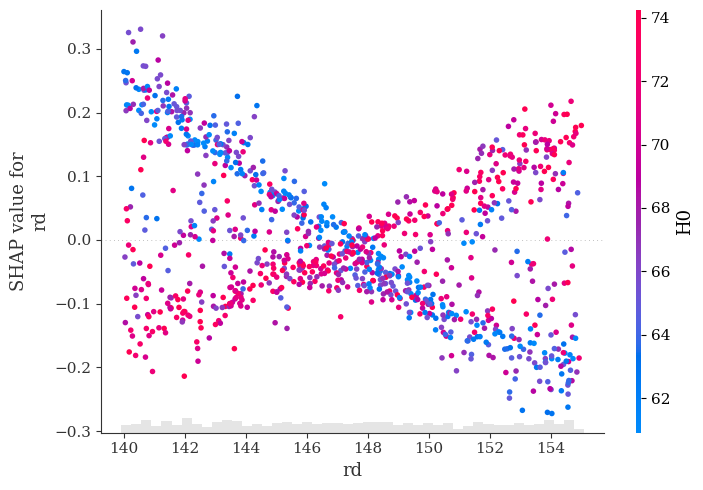

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_7_shap_rd.png')]

In [265]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="BAO degeneración H₀-r_d (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="BAO degeneración H₀-r_d · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-8"></a>3.8 w0waCDM + Planck priors on Om/H0/rd — 5D

**Model:** `Flatw0waCDM` 5D (Om, w0, wa, H0, rd).
**Data:** DESI BAO DR2 + Gaussian Planck 2018 priors on (Om, H0, rd). w0 and wa free.
**Purpose:** combine BAO with the early-universe (Planck) without assuming
anything about dark energy. Priors anchor Om/H0/rd at Planck values and let
us see how BAO constrains (w0, wa) conditionally.

Priors: Om = 0.3153 +/- 0.0073, H0 = 67.36 +/- 0.54, rd = 147.09 +/- 0.26
(all three combined in `cosmoml.priors.planck_prior_chi2`).


In [266]:
SECTION = "3_8"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0", "rd"]

def chi2_fn(Om, w0, wa, H0, rd):
    return (chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=rd)
            + planck_prior_chi2(Om=Om, H0=H0, rd=rd))

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3153, -1.0, 0.0, 67.36, 147.09])))
_m.limits = [(0.25, 0.4), (-1.6, -0.5), (-2.0, 1.0), (60, 75), (140, 155)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}  H0={REF['H0']:.4f}  rd={REF['rd']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3153  w0=-0.8160  wa=-0.5389  H0=67.2310  rd=147.0764
chi2(best-fit) = 8.18


In [267]:
def builder():
    N = 8_000
    pares = [('Om','w0'), ('Om','wa'), ('Om','H0'), ('Om','rd'),
             ('w0','wa'), ('w0','H0'), ('w0','rd'),
             ('wa','H0'), ('wa','rd'), ('H0','rd')]
    rangos = dict(Om=(0.1, 0.6), w0=(-2.5, 0.5), wa=(-4.0, 3.0),
                  H0=(60, 75), rd=(140, 155))
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=0,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")

Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_8_dataset.csv)
Evaluating chi2 at 48000 points across 11 cores...
     2000/48000 (  4.2%) | elapsed    2.9s | ETA   66.0s |    697 pts/s
     4000/48000 (  8.3%) | elapsed    3.6s | ETA   39.2s |   1123 pts/s
     6000/48000 ( 12.5%) | elapsed    4.2s | ETA   29.1s |   1444 pts/s
     8000/48000 ( 16.7%) | elapsed    5.1s | ETA   25.3s |   1582 pts/s
    10000/48000 ( 20.8%) | elapsed    5.7s | ETA   21.8s |   1740 pts/s
    12000/48000 ( 25.0%) | elapsed    6.5s | ETA   19.4s |   1859 pts/s
    14000/48000 ( 29.2%) | elapsed    7.2s | ETA   17.6s |   1936 pts/s
    16000/48000 ( 33.3%) | elapsed    8.1s | ETA   16.3s |   1964 pts/s
    18000/48000 ( 37.5%) | elapsed    9.1s | ETA   15.2s |   1979 pts/s
    20000/48000 ( 41.7%) | elapsed    9.8s | ETA   13.7s |   2043 pts/s
    22000/48000 ( 45.8%) | elapsed   10.6s | ETA   12.5s |   2083 pts/s
    24000/48000 ( 50.0%) | elapsed   11.3s | ETA   11.3s |  

In [268]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  target in shifted-log10: range [0.000, 4.901]
  training: 149.12s | R2=0.99802 | best_iter=1080/3000  (early stop, ~64% saved)
  model cached: 3_8_model.ubj


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_learning_curve.png


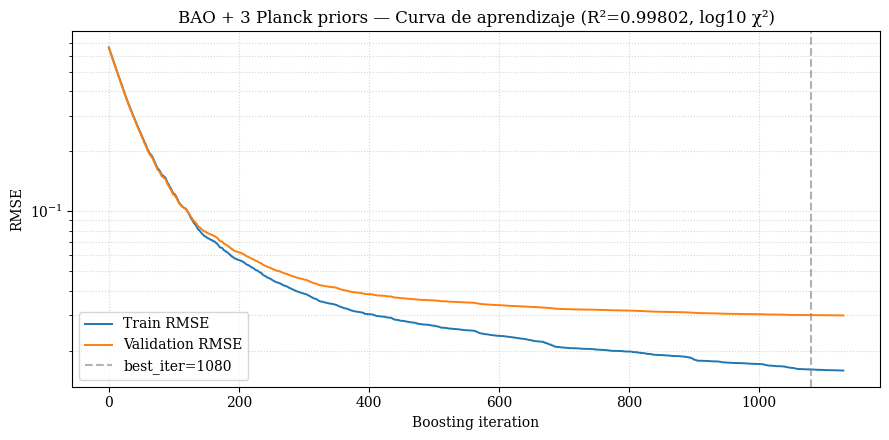

In [269]:
plot_learning_curve(
    info,
    title=f"BAO + 3 Planck priors — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': -0.5388901734372668, 'H0': 67.23099687739101, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_Om_w0.png


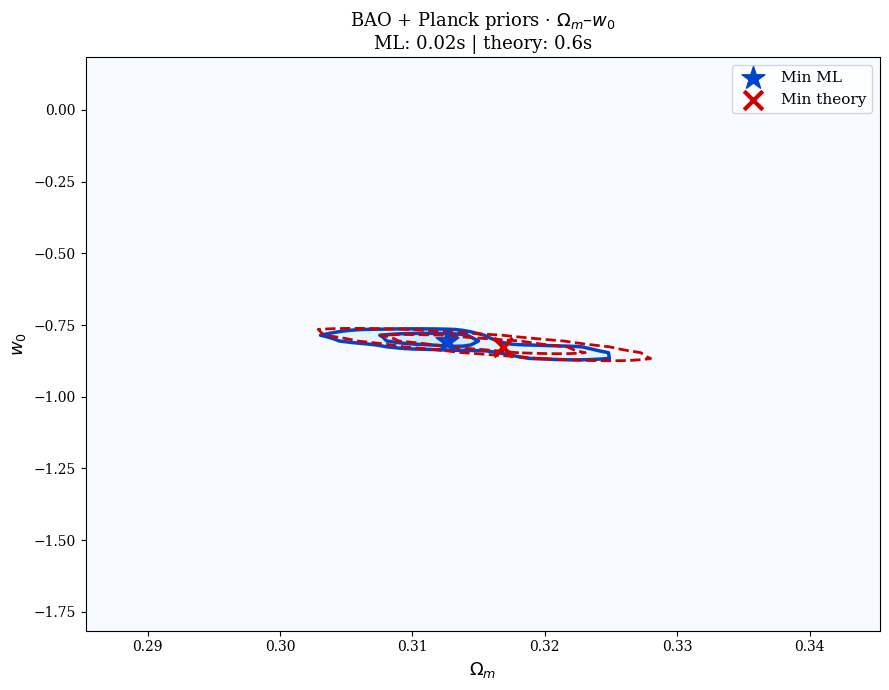

--- $w_a$ vs $\Omega_m$  ({'w0': -0.8159615964547282, 'H0': 67.23099687739101, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_Om_wa.png


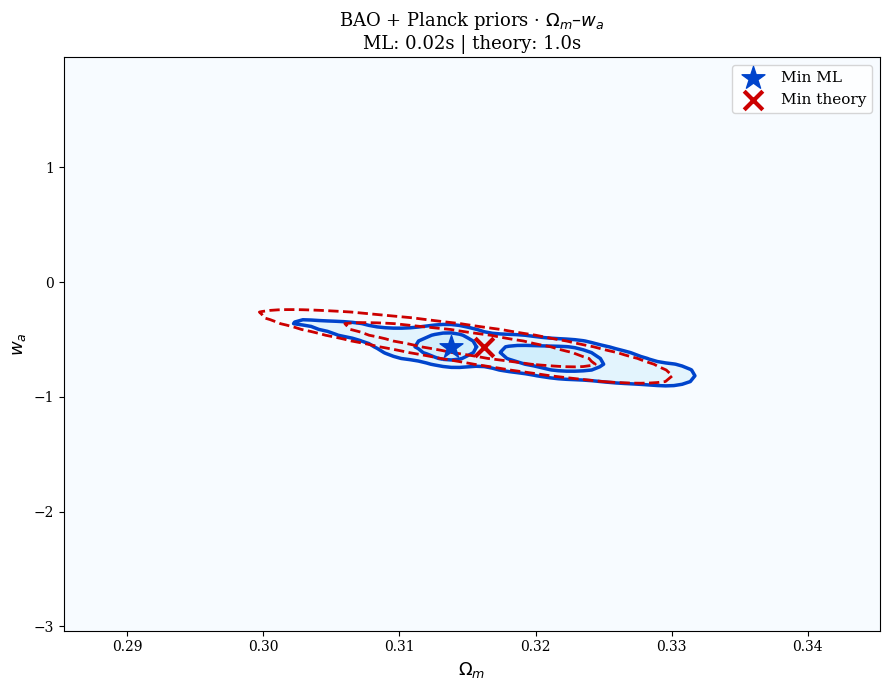

--- $H_0$ vs $\Omega_m$  ({'w0': -0.8159615964547282, 'wa': -0.5388901734372668, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_Om_H0.png


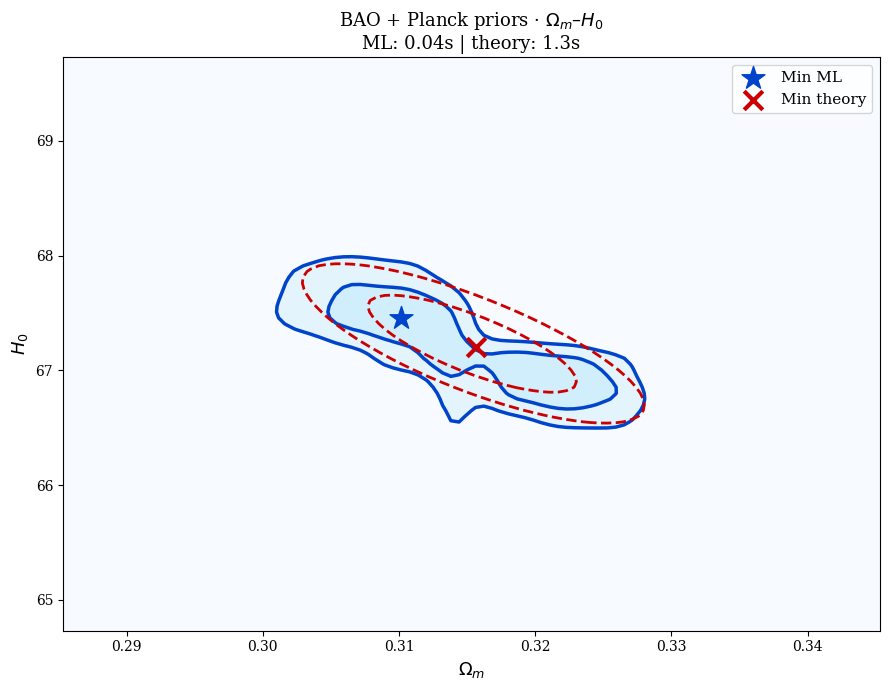

--- $w_a$ vs $w_0$  ({'Om': 0.3153223617569817, 'H0': 67.23099687739101, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_w0_wa.png


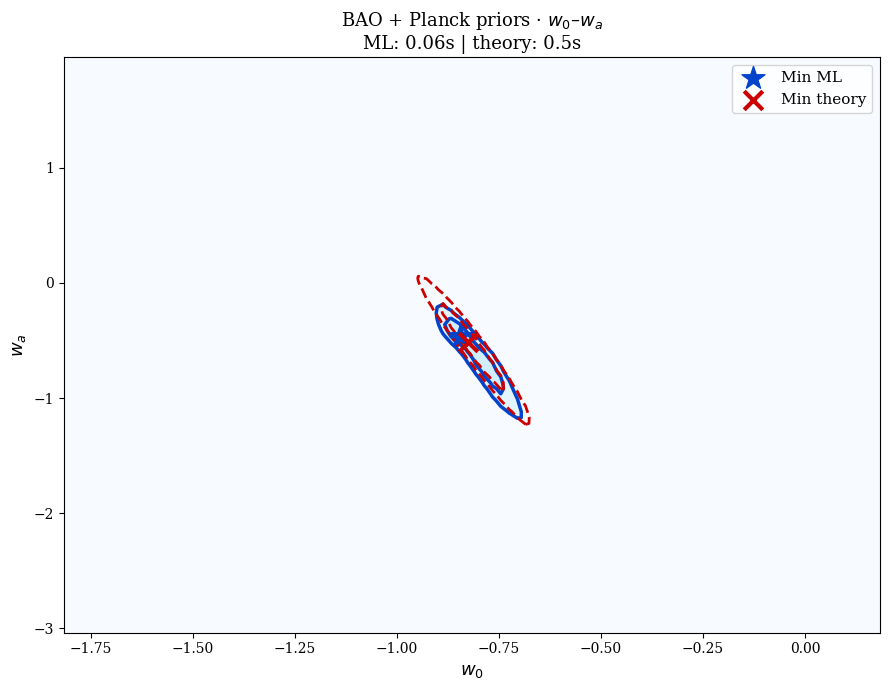

--- $H_0$ vs $w_0$  ({'Om': 0.3153223617569817, 'wa': -0.5388901734372668, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_w0_H0.png


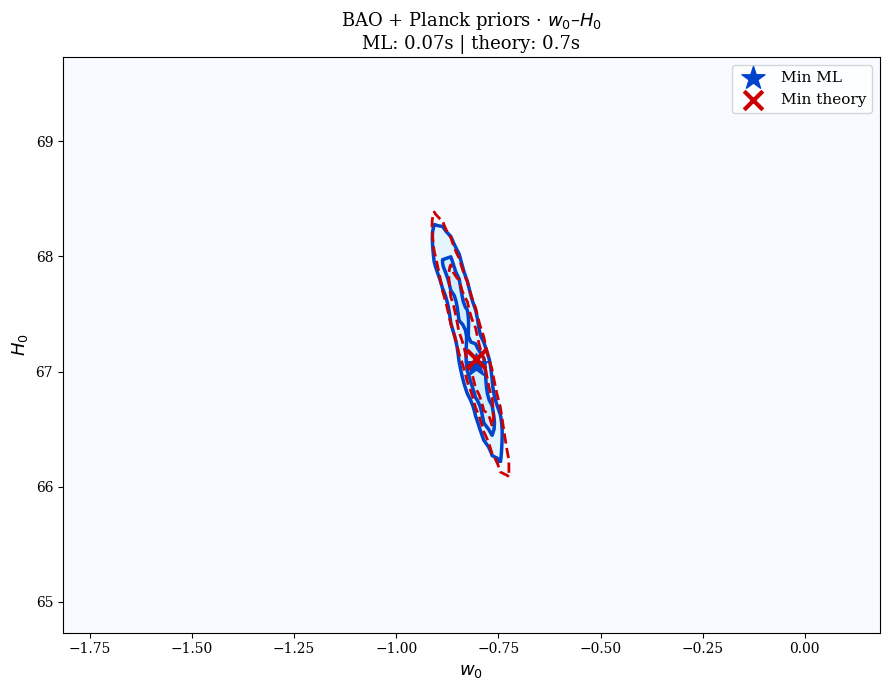

--- $H_0$ vs $w_a$  ({'Om': 0.3153223617569817, 'w0': -0.8159615964547282, 'rd': 147.0764444854717}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_wa_H0.png


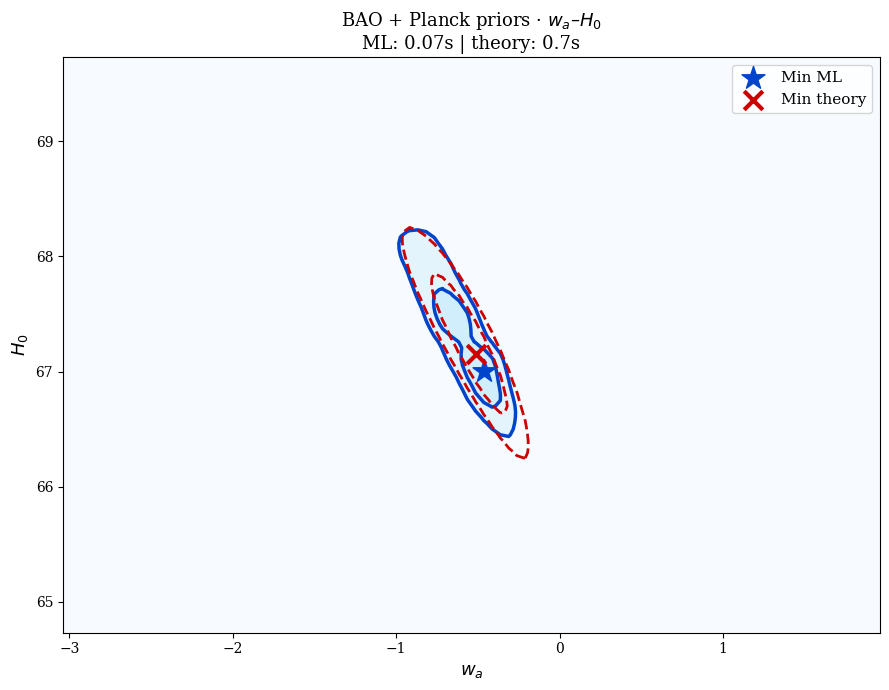

In [270]:
common = dict(res=100, sigma=2.0, theory_threshold=20)
RANGES = dict(
    Om=(REF['Om'] - 0.03, REF['Om'] + 0.03),
    w0=(REF['w0'] - 1.0,  REF['w0'] + 1.0),
    wa=(REF['wa'] - 2.5,  REF['wa'] + 2.5),
    H0=(REF['H0'] - 2.5,  REF['H0'] + 2.5),
    rd=(REF['rd'] - 2.5,  REF['rd'] + 2.5),
)
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0=r"$H_0$", rd=r"$r_d$")

for x, y in [('Om','w0'), ('Om','wa'), ('Om','H0'), ('Om','rd'),
             ('w0','wa'), ('w0','H0'), ('w0','rd'),
             ('wa','H0'), ('wa','rd'), ('H0','rd')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"BAO + Planck priors · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_beeswarm.png


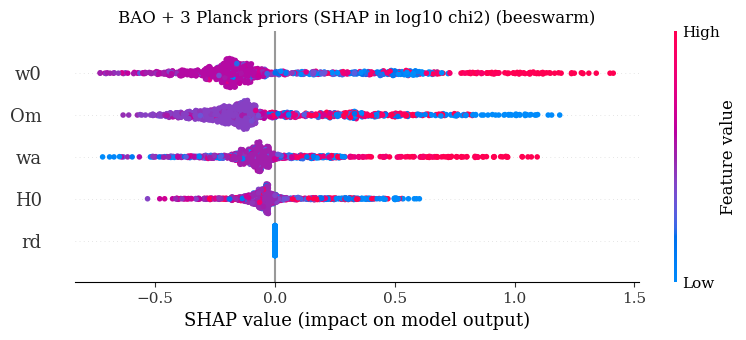

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_bar.png


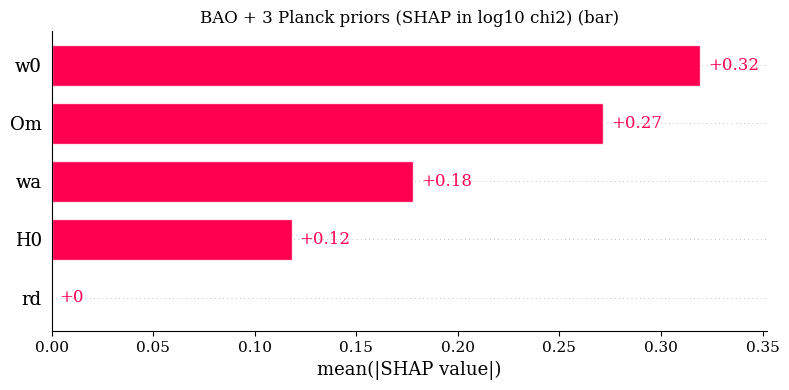

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_waterfall.png


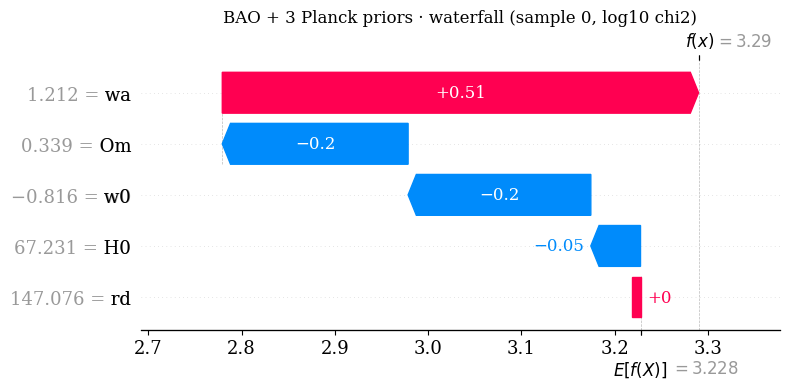

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_Om.png


<Figure size 640x480 with 0 Axes>

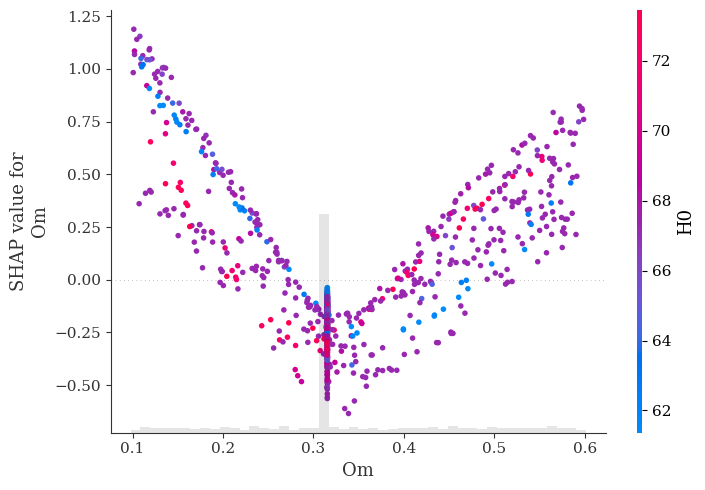

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_w0.png


<Figure size 640x480 with 0 Axes>

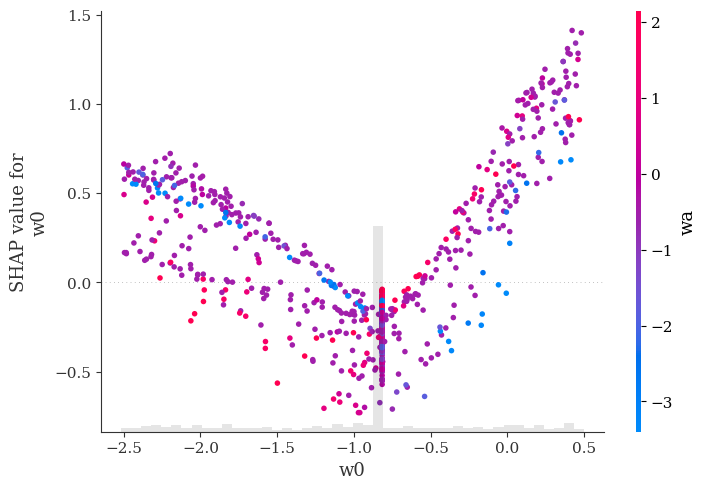

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_wa.png


<Figure size 640x480 with 0 Axes>

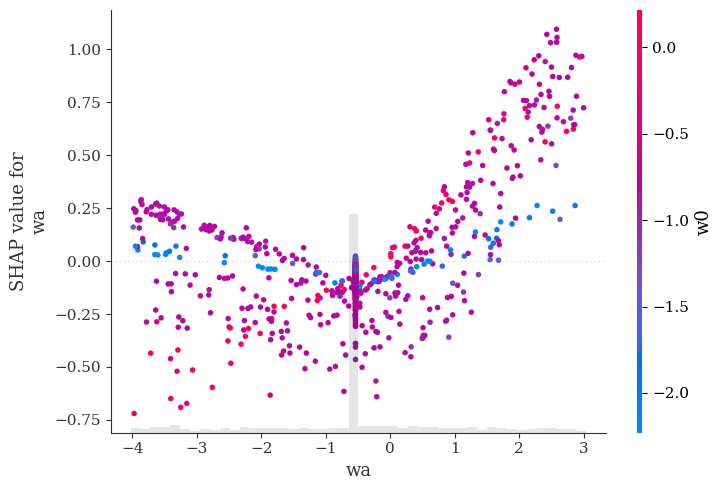

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_H0.png


<Figure size 640x480 with 0 Axes>

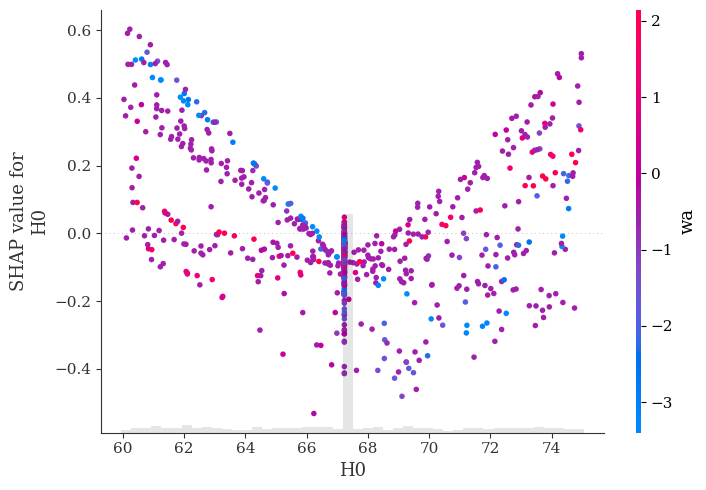

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_rd.png


<Figure size 640x480 with 0 Axes>

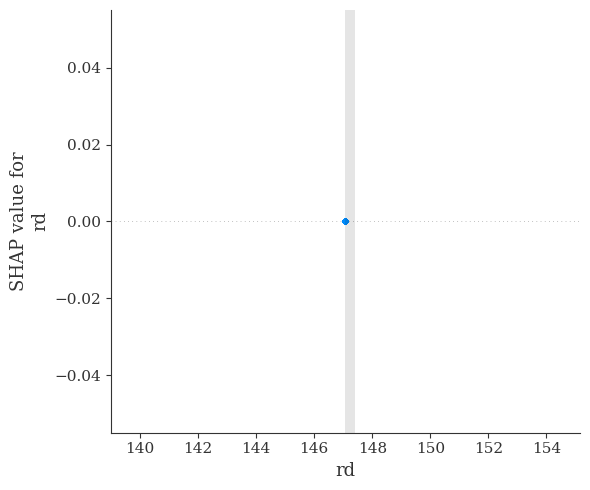

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_8_shap_rd.png')]

In [271]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="BAO + 3 Planck priors (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="BAO + 3 Planck priors · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)

## <a id="3-9"></a>3.9 w0waCDM + 5 Planck priors (all) — 5D

**Model:** same 5D as 3.8.
**Data:** DESI BAO DR2 + 5 Gaussian priors: Planck on Om, H0, rd, **plus**
Planck+SNe+BAO 2018 on w0, wa (w0 = -0.961 +/- 0.077, wa = -0.28 +/- 0.29).
**Purpose:** the **most constrained scenario.** With priors on all parameters,
the contours tighten as much as possible — useful for seeing how far the
combination can be pushed.

REF is re-anchored to the numerical best-fit (priors shift the center away
from the bare Planck values).


In [272]:
SECTION = "3_9"
DATASET_CSV = DATASETS_DIR / f"{SECTION}_dataset.csv"
FEATURES = ["Om", "w0", "wa", "H0", "rd"]

W0_PRIOR = (-0.961, 0.077)
WA_PRIOR = (-0.28, 0.29)

def chi2_fn(Om, w0, wa, H0, rd):
    return (chi2_bao(bao_full, Om=Om, w0=w0, wa=wa, H0=H0, rd=rd)
            + planck_prior_chi2(Om=Om, H0=H0, rd=rd)
            + gaussian_prior(w0, *W0_PRIOR)
            + gaussian_prior(wa, *WA_PRIOR))

# Auto-center: locate the best-fit with Minuit
import types
from iminuit import Minuit
print("Locating the global minimum with Minuit...")
_m = Minuit(chi2_fn, **dict(zip(FEATURES, [0.3153, -0.961, -0.28, 67.36, 147.09])))
_m.limits = [(0.28, 0.35), (-1.2, -0.7), (-1.0, 0.5), (65, 70), (145, 150)]
_m.migrad()
res_opt = types.SimpleNamespace(fun=_m.fval, x=[float(_m.values[k]) for k in FEATURES])
REF = dict(zip(FEATURES, res_opt.x))
print(f"Auto-detected best-fit:  Om={REF['Om']:.4f}  w0={REF['w0']:.4f}  wa={REF['wa']:.4f}  H0={REF['H0']:.4f}  rd={REF['rd']:.4f}")
print(f"chi2(best-fit) = {res_opt.fun:.2f}")


Locating the global minimum with Minuit...
Auto-detected best-fit:  Om=0.3131  w0=-0.8823  wa=-0.2888  H0=67.4759  rd=147.1026
chi2(best-fit) = 10.13


In [273]:
def builder():
    N = 6_000
    pares = [('Om','w0'), ('Om','wa'), ('Om','H0'), ('Om','rd'),
             ('w0','wa'), ('w0','H0'), ('w0','rd'),
             ('wa','H0'), ('wa','rd'), ('H0','rd')]
    sigmas = dict(Om=0.0073, w0=0.077, wa=0.29, H0=0.54, rd=0.26)
    rangos = {k: (REF[k]-3.5*sigmas[k], REF[k]+3.5*sigmas[k]) for k in FEATURES}
    slices = [{**REF, a: rangos[a], b: rangos[b], '_n': N} for a, b in pares]
    return build_chi2_dataset(
        chi2_fn=chi2_fn, param_names=FEATURES,
        slices=slices, n_random=0,
        save_to=DATASET_CSV, seed=42,
    )

df = load_or_build(DATASET_CSV, builder, force=False)
print(f"min chi2 = {df['chi2'].min():.3f}")


Building dataset (cache missing: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_9_dataset.csv)
  optimizing 5D chi2...
  best-fit numérico: {'Om': 0.3131003517360098, 'w0': -0.88231420309408, 'wa': -0.2889678157012027, 'H0': 67.4766792407065, 'rd': 147.10284707891483}, χ²=10.128
  saved: /home/aleja/PhysicsML/CosmoML/outputs/datasets/3_9_dataset.csv  (56000 rows)
min chi2 = 10.134
Dataset best-fit:
  Om    = 0.3131
  w0    = -0.8842
  wa    = -0.2778
  H0    = 67.4767
  rd    = 147.1028


In [274]:
model, info = train_xgb(
    df, features=FEATURES,
    log_target=True,
    test_size=0.15,
    hp_overrides=dict(n_estimators=3000, learning_rate=0.03, max_depth=10),
    cache_path=MODELS_DIR / f"{SECTION}_model.ubj",
    force_retrain=FORCE_RETRAIN,
)

  target in shifted-log10: range [0.000, 4.095]
  training: 19.98s | R2=0.98479 | best_iter=1269/3000  (early stop, ~58% saved)
  model cached: 3_9_model.ubj


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_learning_curve.png


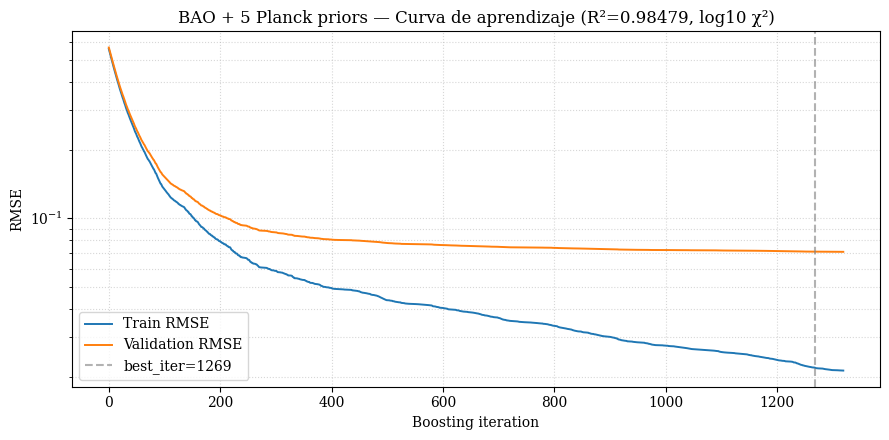

In [275]:
plot_learning_curve(
    info,
    title=f"BAO + 5 Planck priors — Curva de aprendizaje (R²={info['r2']:.5f}, log10 χ²)",
    save_path=FIGURES_DIR / f"{SECTION}_learning_curve.png",
    show=True,
)

--- $w_0$ vs $\Omega_m$  ({'wa': -0.27782816159692514, 'H0': 67.4766792407065, 'rd': 147.10284707891483}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_Om_w0.png


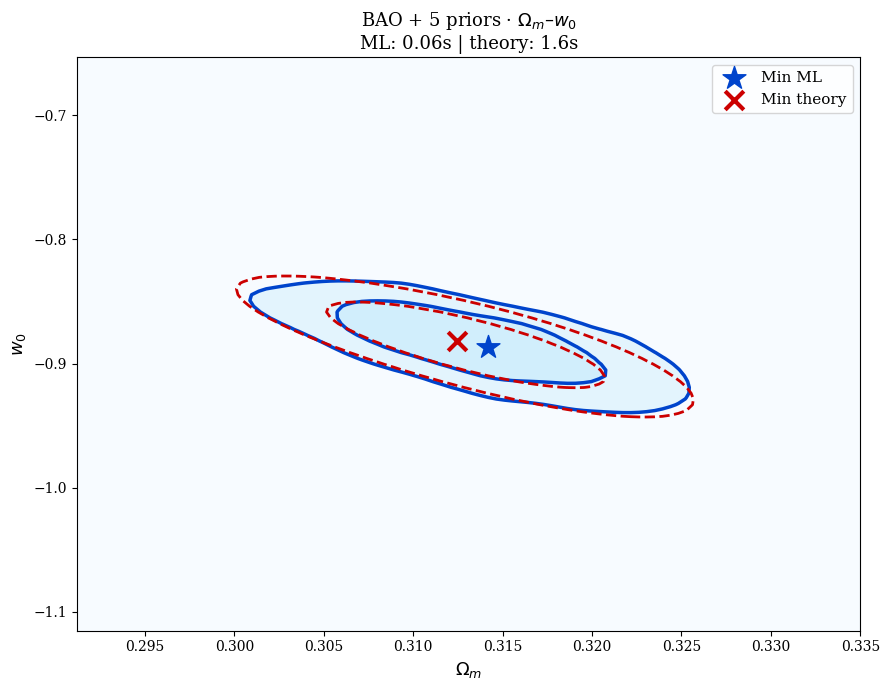

--- $w_a$ vs $w_0$  ({'Om': 0.3131003517360098, 'H0': 67.4766792407065, 'rd': 147.10284707891483}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_w0_wa.png


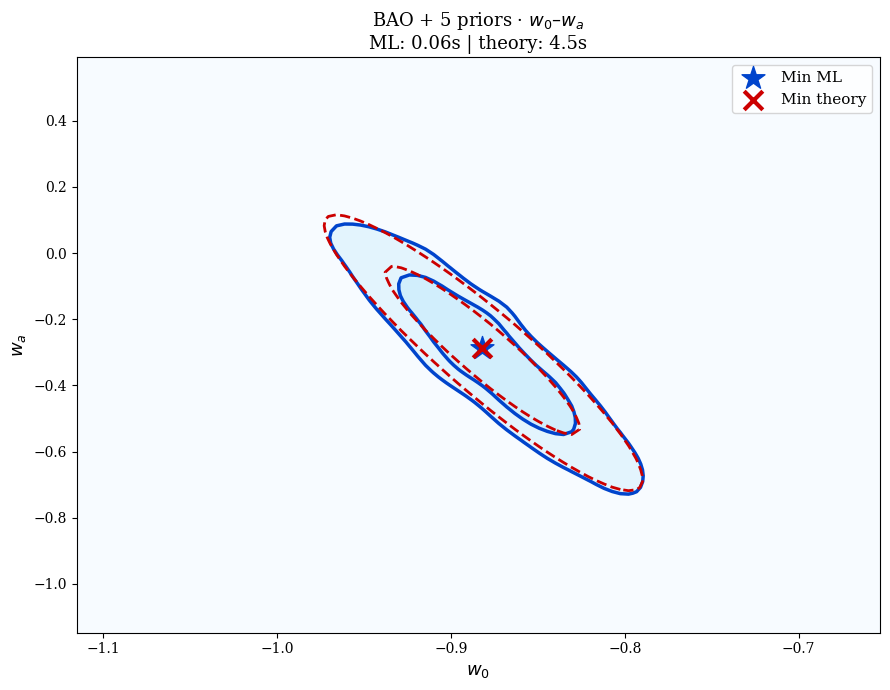

--- $w_0$ vs $H_0$  ({'Om': 0.3131003517360098, 'wa': -0.27782816159692514, 'rd': 147.10284707891483}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_H0_w0.png


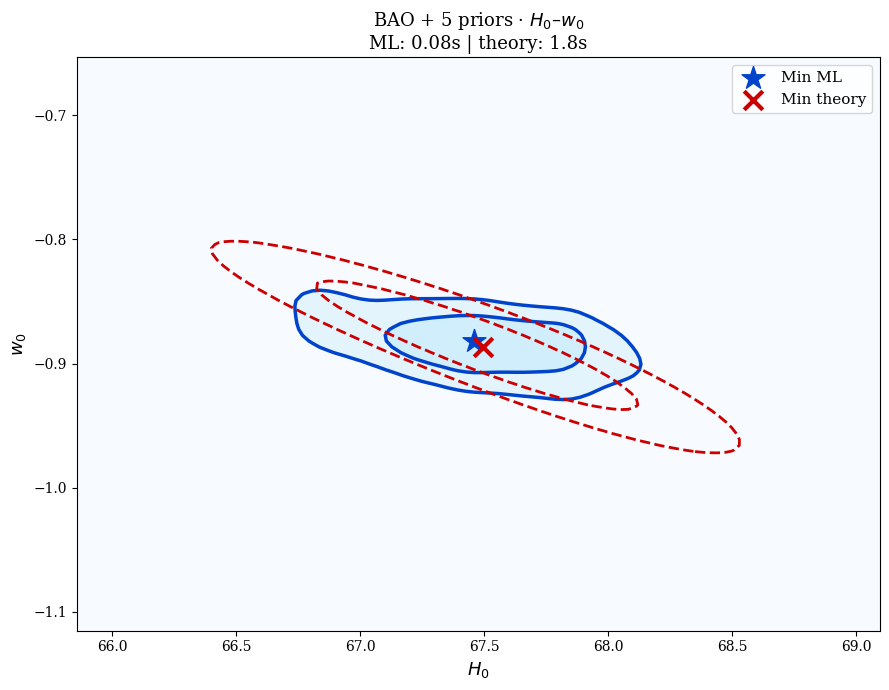

--- $H_0$ vs $\Omega_m$  ({'w0': -0.8842212999049102, 'wa': -0.27782816159692514, 'rd': 147.10284707891483}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_Om_H0.png


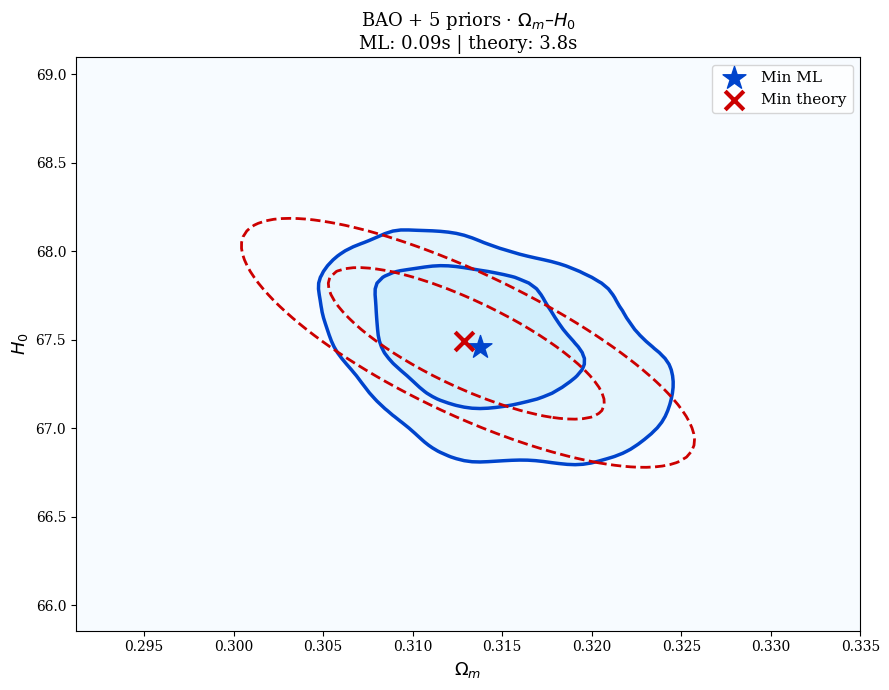

--- $H_0$ vs $r_d$  ({'Om': 0.3131003517360098, 'w0': -0.8842212999049102, 'wa': -0.27782816159692514}) ---
  computing theory (parallel)...
  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_rd_H0.png


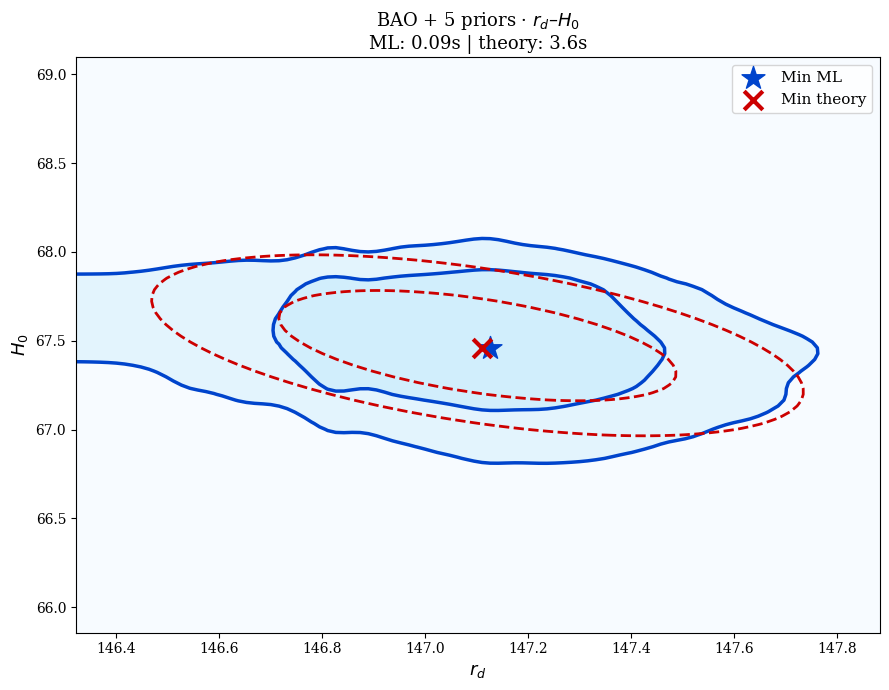

In [276]:
common = dict(res=100, sigma=2.0, theory_threshold=30)
SIGMAS = dict(Om=0.0073, w0=0.077, wa=0.29, H0=0.54, rd=0.26)
RANGES = {k: (REF[k] - 3*SIGMAS[k], REF[k] + 3*SIGMAS[k]) for k in FEATURES}
LABELS = dict(Om=r"$\Omega_m$", w0=r"$w_0$", wa=r"$w_a$", H0=r"$H_0$", rd=r"$r_d$")

for x, y in [('Om','w0'), ('w0','wa'), ('H0','w0'), ('Om','H0'), ('rd','H0')]:
    fixed = {k: REF[k] for k in FEATURES if k not in (x, y)}
    plot_contour_2d(
        model, features=FEATURES,
        x_param=x, y_param=y,
        x_range=RANGES[x], y_range=RANGES[y],
        fixed=fixed, theory_fn=chi2_fn,
        title=fr"BAO + 5 priors · {LABELS[x]}–{LABELS[y]}",
        x_label=LABELS[x], y_label=LABELS[y],
        save_path=FIGURES_DIR / f"{SECTION}_{x}_{y}.png",
        show=True, **common,
        global_min_chi2=res_opt.fun,
    )


  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_beeswarm.png


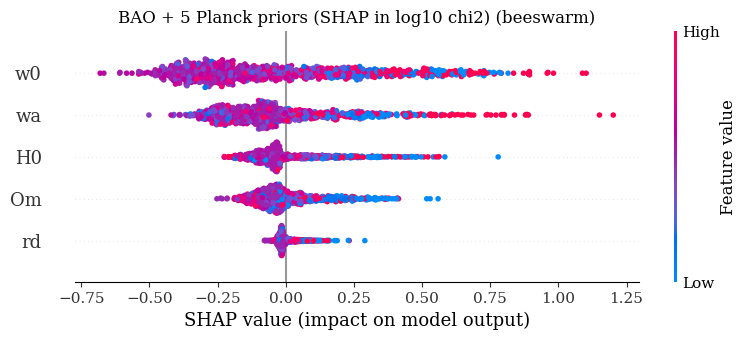

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_bar.png


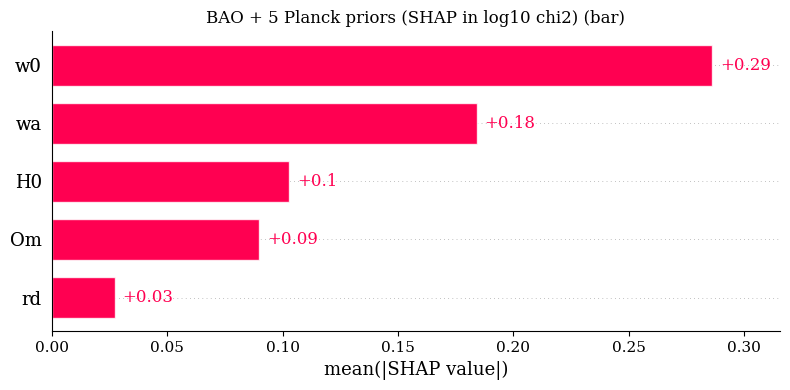

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_waterfall.png


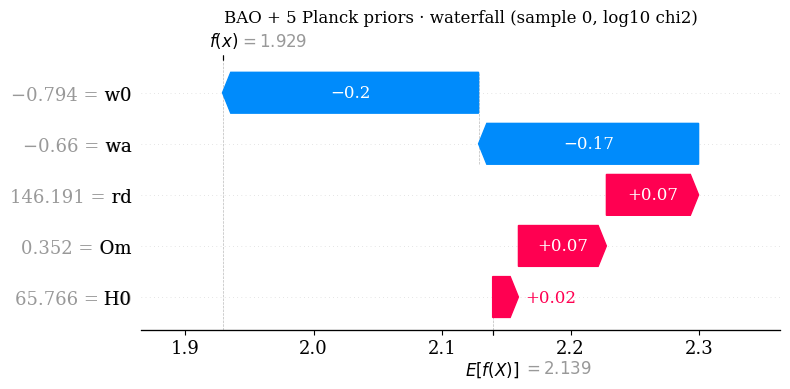

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_Om.png


<Figure size 640x480 with 0 Axes>

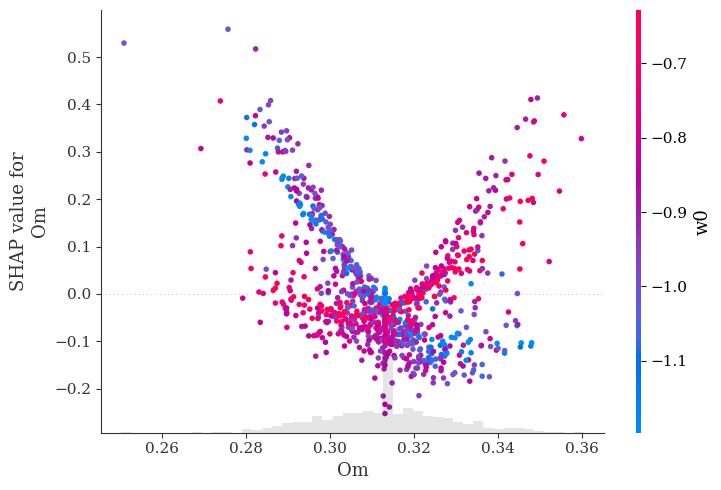

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_w0.png


<Figure size 640x480 with 0 Axes>

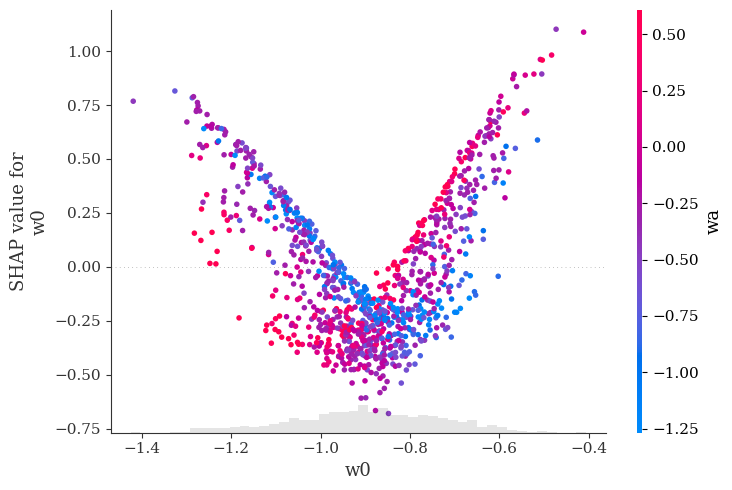

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_wa.png


<Figure size 640x480 with 0 Axes>

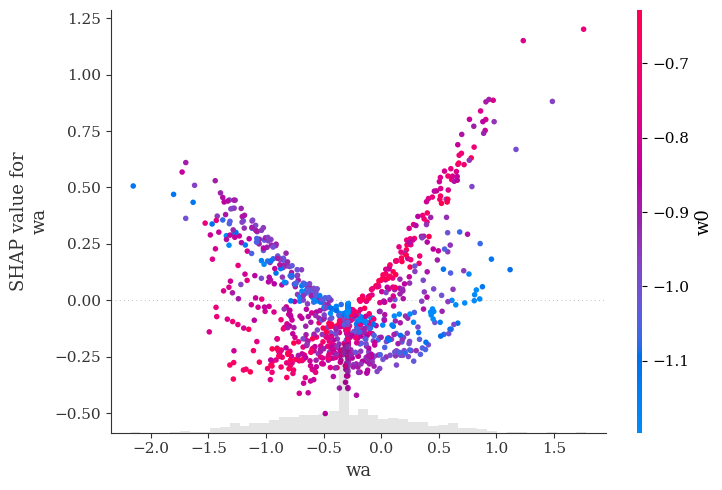

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_H0.png


<Figure size 640x480 with 0 Axes>

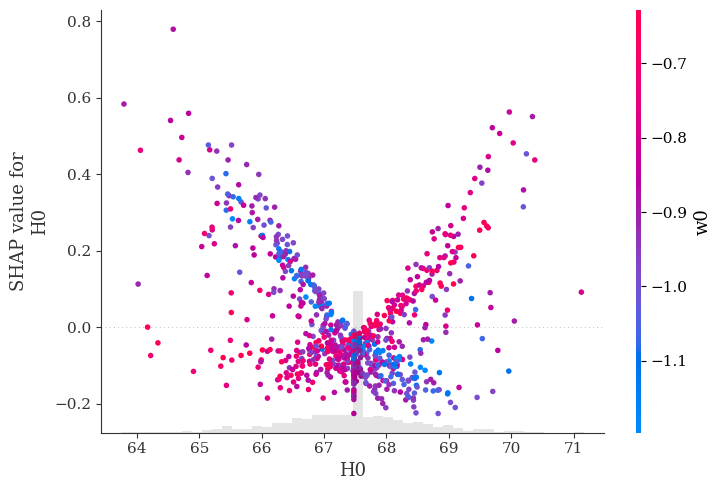

  saved: /home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_rd.png


<Figure size 640x480 with 0 Axes>

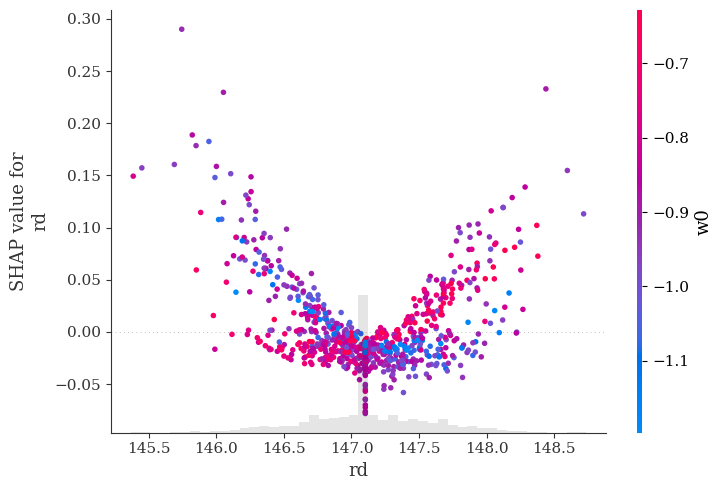

[PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_Om.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_w0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_wa.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_H0.png'),
 PosixPath('/home/aleja/PhysicsML/CosmoML/outputs/figures/03_BAO/3_9_shap_rd.png')]

In [277]:
shap_v, X_s = shap_summary(
    model, info["X_val"],
    save_dir=FIGURES_DIR, prefix=SECTION,
    title="BAO + 5 Planck priors (SHAP in log10 chi2)",
    show=True,
)
shap_waterfall(
    shap_v, idx=0,
    save_path=FIGURES_DIR / f"{SECTION}_shap_waterfall.png",
    title="BAO + 5 Planck priors · waterfall (sample 0, log10 chi2)",
    show=True,
)
shap_dependence_all(
    shap_v, X_s,
    save_dir=FIGURES_DIR, prefix=SECTION,
    show=True,
)